# Лабораторная работа №3. Классификация и прогнозирование метеоданных

**Двухэтапная система анализа метеорологических временных рядов шести городов России** (Москва, Санкт‑Петербург, Сочи, Геленджик, Благовещенск, Находка), 2019–2025 гг.

1. **Классификация** — по окну метеопараметров определяем, к какому городу/типу климата относится ряд.
2. **Прогнозирование** — для каждого города обучаем свою модель прогноза температуры на 30 дней вперёд.

Ноутбук полностью реализует пайплайн и состоит из следующих секций:

| Секция | Пункт ЛР | Содержание |
| --- | --- | --- |
| §0 | — | Setup, загрузка данных, ресемплинг |
| §1 | 2.1 | Разведочный анализ (EDA) |
| §2 | 2.2 | Инжиниринг признаков |
| §3 | 2.3 | Построение модели классификации |
| §4 | 2.4 | Оценка качества классификации |
| §5 | 2.5 | Построение моделей прогнозирования |
| §6 | 2.6 | Оценка качества прогнозирования |
| §7 | 2.7 | Единый пайплайн |
| §8 | 2.8 | Документирование и итоговые выводы |


## §0. Setup

В этой секции:
- импортируем библиотеки и фиксируем сиды;
- задаём глобальный конфиг (список городов, пути, колонки, параметры сплита);
- загружаем parquet‑файлы за 2019–2025 гг. для всех шести городов;
- выполняем ресемплинг часовых данных к дневной частоте (по условиям задачи прогнозируем на месяц вперёд — дневная частота оптимальна).


In [73]:
from __future__ import annotations

import os
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["font.family"] = "DejaVu Sans"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [74]:
DATA_DIR = Path("data")

CITIES: List[str] = [
    "Москва",
    "Санкт-Петербург",
    "Сочи",
    "Геленджик",
    "Благовещенск",
    "Находка",
]

CLIMATE_GROUPS: Dict[str, str] = {
    "Москва": "умеренно-континентальный",
    "Санкт-Петербург": "умеренно-континентальный",
    "Сочи": "субтропический",
    "Геленджик": "субтропический",
    "Благовещенск": "муссонно-континентальный",
    "Находка": "муссонно-континентальный",
}

YEARS: List[int] = list(range(2019, 2026))

RAW_FEATURES: List[str] = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
]

# сплит по годам без утечек данных
TRAIN_YEARS = list(range(2019, 2024))
VAL_YEARS = [2024]
TEST_YEARS = [2025]

WINDOW_DAYS = 30
FORECAST_HORIZON = 30

print("CITIES:", CITIES)
print("CLIMATES:", set(CLIMATE_GROUPS.values()))
print(f"Window for classification: {WINDOW_DAYS} days, forecast horizon: {FORECAST_HORIZON} days")


CITIES: ['Москва', 'Санкт-Петербург', 'Сочи', 'Геленджик', 'Благовещенск', 'Находка']
CLIMATES: {'умеренно-континентальный', 'муссонно-континентальный', 'субтропический'}
Window for classification: 30 days, forecast horizon: 30 days


In [75]:
def load_city_hourly(city: str, data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Склеивает все годовые parquet-файлы одного города в один DataFrame
    с DatetimeIndex частоты 1 ч."""
    parts: List[pd.DataFrame] = []
    for year in YEARS:
        fname = f"{city}_{year}-01-01_{year}-12-31.parquet"
        path = data_dir / fname
        if not path.exists():
            print(f"[warn] файл не найден: {path}")
            continue
        df = pd.read_parquet(path)
        parts.append(df)
    full = pd.concat(parts).sort_index()
    full = full[~full.index.duplicated(keep="first")]
    # приведение к регулярной часовой сетке (заполнит отсутствующие часы NaN)
    idx = pd.date_range(full.index.min(), full.index.max(), freq="h")
    full = full.reindex(idx)
    full.index.name = "time"
    return full


def load_all_hourly(cities: List[str] = CITIES) -> Dict[str, pd.DataFrame]:
    return {c: load_city_hourly(c) for c in cities}


hourly: Dict[str, pd.DataFrame] = load_all_hourly()

summary = pd.DataFrame(
    {
        "rows": {c: df.shape[0] for c, df in hourly.items()},
        "start": {c: df.index.min() for c, df in hourly.items()},
        "end": {c: df.index.max() for c, df in hourly.items()},
        "n_missing_T": {c: int(df["temperature_2m"].isna().sum()) for c, df in hourly.items()},
    }
)
summary


,rows,start,end,n_missing_T
Москва,61368,2019-01-01,2025-12-31 23:00:00,0
Санкт-Петербург,61368,2019-01-01,2025-12-31 23:00:00,0
Сочи,61368,2019-01-01,2025-12-31 23:00:00,0
Геленджик,61368,2019-01-01,2025-12-31 23:00:00,0
Благовещенск,61368,2019-01-01,2025-12-31 23:00:00,0
Находка,61368,2019-01-01,2025-12-31 23:00:00,0


In [76]:
def resample_to_daily(df_hourly: pd.DataFrame) -> pd.DataFrame:
    """Агрегация к дневной частоте.

    - температура, влажность, давление, ветер  -> среднее;
    - осадки, дождь, снег -> сумма за сутки;
    - weathercode -> мода (наиболее частый код за сутки);
    - плюс служебные признаки: min/max температуры и амплитуда (для EDA).
    """
    agg_mean = ["temperature_2m", "relative_humidity_2m", "surface_pressure", "wind_speed_10m"]
    agg_sum = ["precipitation", "rain", "snowfall"]

    daily_mean = df_hourly[agg_mean].resample("D").mean()
    daily_sum = df_hourly[agg_sum].resample("D").sum(min_count=1)

    def _mode(x: pd.Series) -> float:
        x = x.dropna()
        return float(x.mode().iloc[0]) if len(x) else np.nan

    daily_code = df_hourly["weathercode"].resample("D").apply(_mode).rename("weathercode")

    daily_tmin = df_hourly["temperature_2m"].resample("D").min().rename("temperature_min")
    daily_tmax = df_hourly["temperature_2m"].resample("D").max().rename("temperature_max")
    daily_trange = (daily_tmax - daily_tmin).rename("temperature_range")

    daily = pd.concat([daily_mean, daily_sum, daily_code, daily_tmin, daily_tmax, daily_trange], axis=1)
    daily.index.name = "date"
    return daily


daily: Dict[str, pd.DataFrame] = {c: resample_to_daily(df) for c, df in hourly.items()}

preview = pd.DataFrame(
    {
        "days": {c: len(df) for c, df in daily.items()},
        "nan_%": {c: round(df.isna().mean().mean() * 100, 3) for c, df in daily.items()},
        "mean_T": {c: round(df["temperature_2m"].mean(), 2) for c, df in daily.items()},
        "sum_precip": {c: round(df["precipitation"].sum(), 1) for c, df in daily.items()},
    }
)
preview


,days,nan_%,mean_T,sum_precip
Москва,2557,0.0,6.83,4745.000000
Санкт-Петербург,2557,0.0,6.79,5014.399902
Сочи,2557,0.0,15.04,11547.700195
Геленджик,2557,0.0,14.36,6634.000000
Благовещенск,2557,0.0,2.21,4447.299805
Находка,2557,0.0,6.99,6225.000000


**Вывод §0.** Загружены данные шести городов за 2019–2025 гг. с часовой дискретностью; далее работа ведётся на дневной агрегации — это стандарт для задач прогноза на горизонт ≥ месяца (мы фильтруем суточный шум, сохраняя синоптические и сезонные сигналы). В колонке `temperature_range` получаем суточную амплитуду температур — важный различающий признак для классификации климатов.


## §1. Разведочный анализ данных (п. 2.1)

Цели:
- визуально оценить тренды, суточную и годовую сезонность, выбросы и пропуски;
- изучить распределения признаков (гистограммы, box‑plot, Q‑Q plot, Шапиро‑Уилк);
- выявить сезонные паттерны по месяцам/временам года;
- построить корреляционные матрицы по каждому городу;
- провести кросс‑городское сравнение температуры и осадков, построить климатические профили;
- проанализировать пропуски и обосновать стратегию их обработки;
- проверить стационарность рядов (ADF/KPSS) и обосновать необходимость дифференцирования.


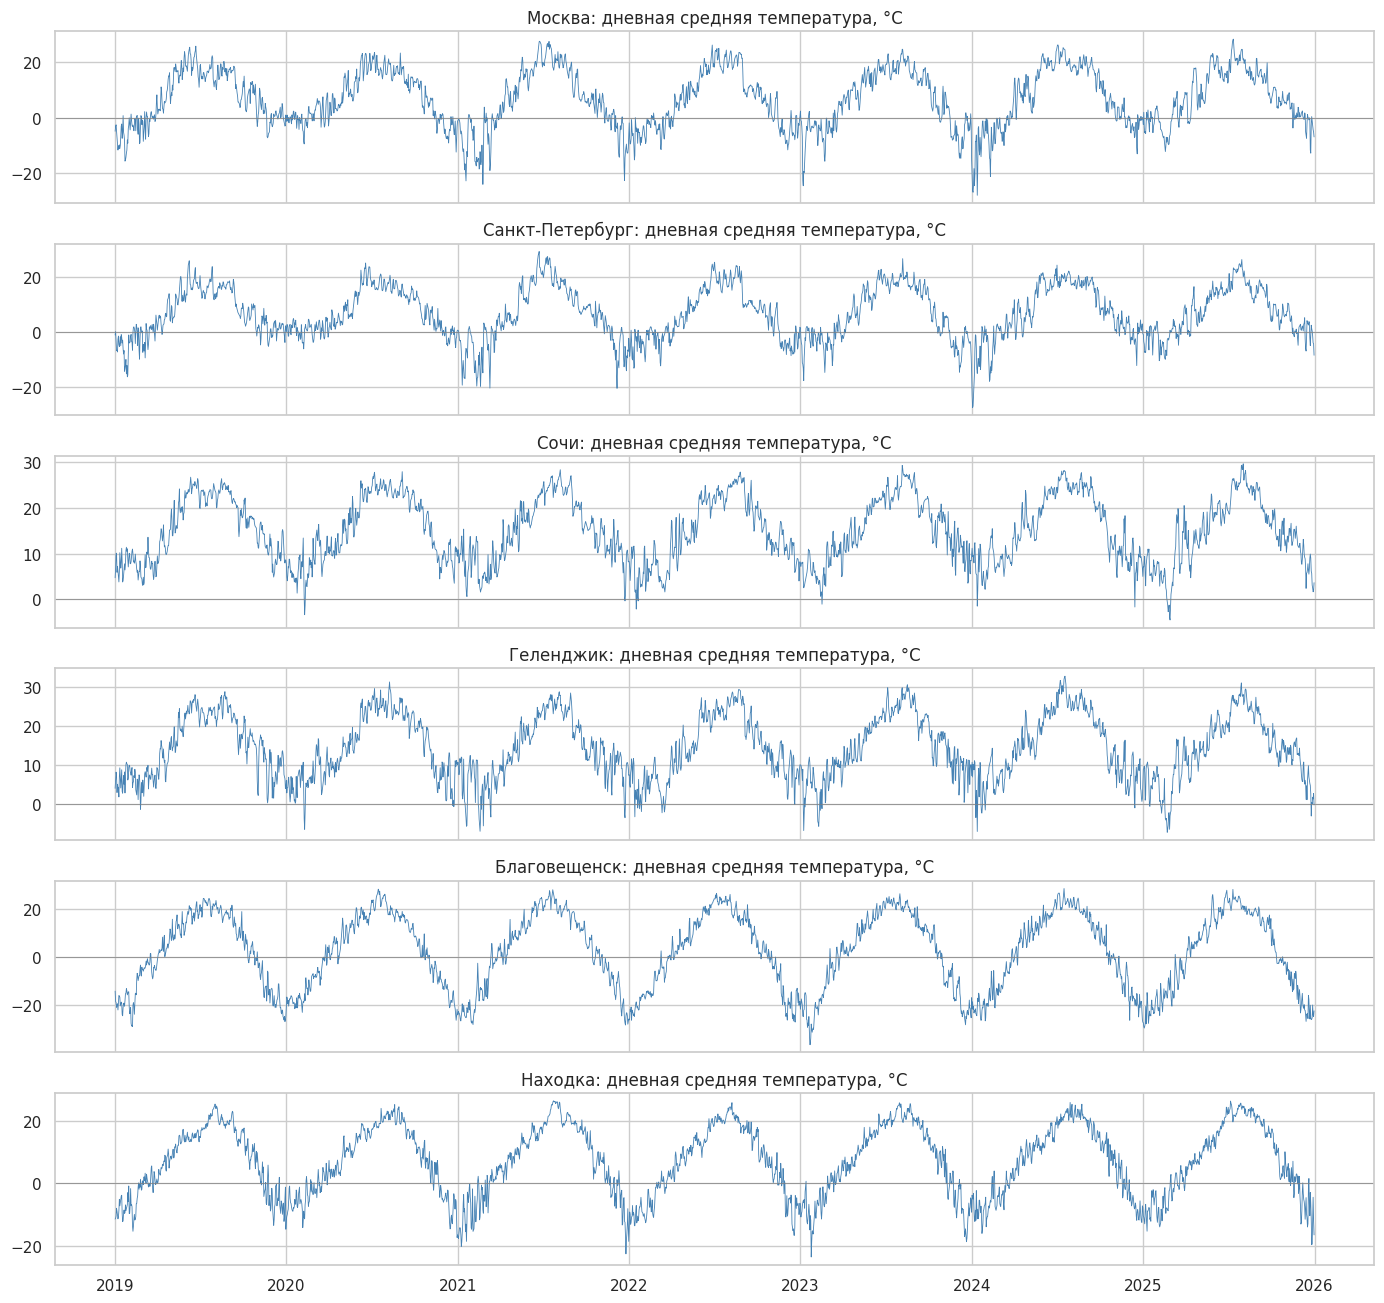

In [77]:
fig, axes = plt.subplots(len(CITIES), 1, figsize=(14, 2.2 * len(CITIES)), sharex=True)
for ax, city in zip(axes, CITIES):
    ts = daily[city]["temperature_2m"]
    ax.plot(ts.index, ts.values, lw=0.6, color="steelblue")
    ax.set_title(f"{city}: дневная средняя температура, °C")
    ax.axhline(0, color="grey", lw=0.5)
fig.tight_layout()
plt.show()


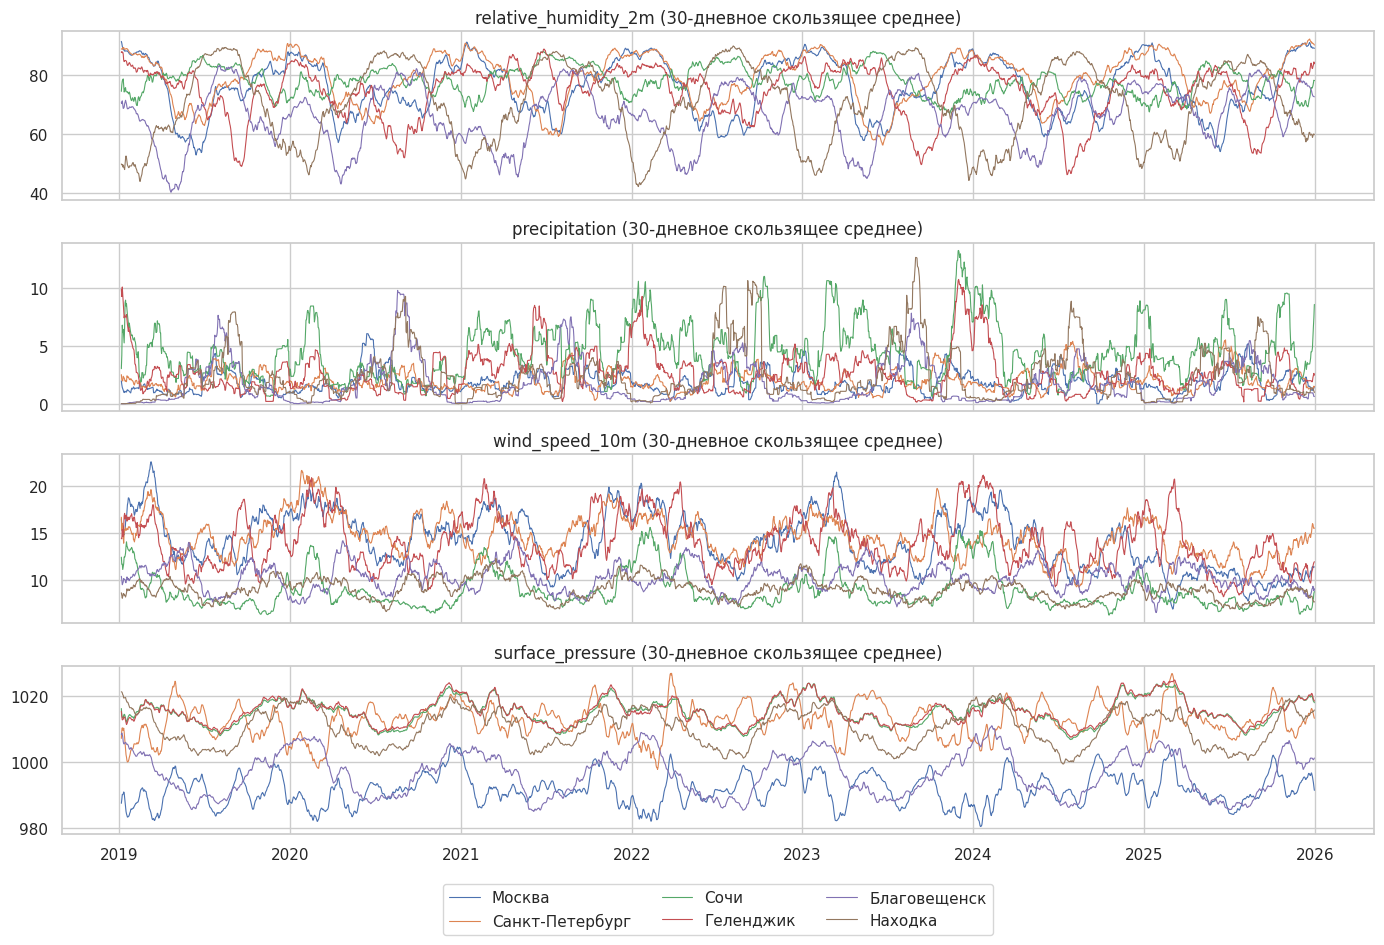

In [78]:
other_features = ["relative_humidity_2m", "precipitation", "wind_speed_10m", "surface_pressure"]

fig, axes = plt.subplots(len(other_features), 1, figsize=(14, 2.4 * len(other_features)), sharex=True)
for ax, feat in zip(axes, other_features):
    for city in CITIES:
        s = daily[city][feat].rolling(30, min_periods=5).mean()
        ax.plot(s.index, s.values, lw=0.8, label=city)
    ax.set_title(f"{feat} (30-дневное скользящее среднее)")
axes[-1].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.25))
fig.tight_layout()
plt.show()


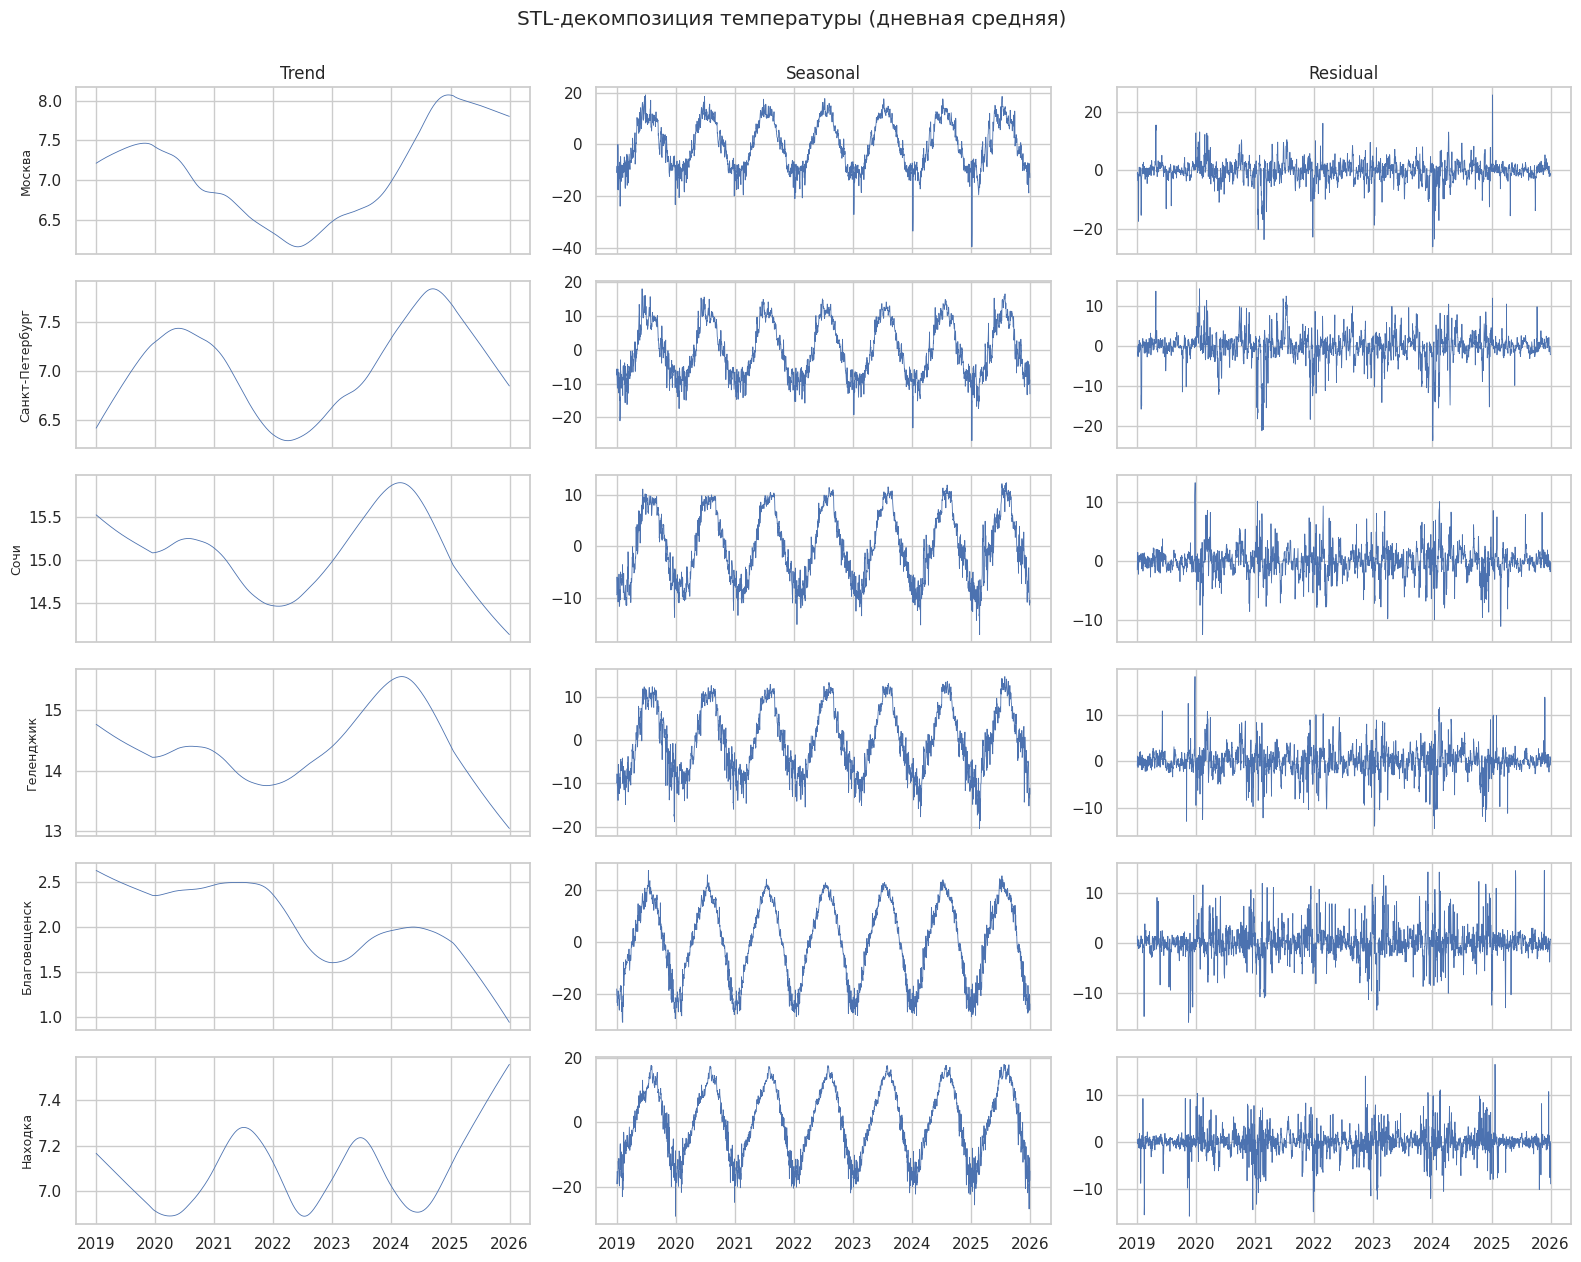

In [79]:
from statsmodels.tsa.seasonal import STL

fig, axes = plt.subplots(len(CITIES), 3, figsize=(16, 2.1 * len(CITIES)), sharex=True)
for row, city in enumerate(CITIES):
    ts = daily[city]["temperature_2m"].interpolate(method="time")
    stl = STL(ts, period=365, robust=True).fit()
    for col, (component, label) in enumerate([(stl.trend, "Trend"), (stl.seasonal, "Seasonal"), (stl.resid, "Residual")]):
        axes[row, col].plot(component.index, component.values, lw=0.6)
        if row == 0:
            axes[row, col].set_title(label)
        if col == 0:
            axes[row, col].set_ylabel(city, fontsize=9)
fig.suptitle("STL-декомпозиция температуры (дневная средняя)", y=1.00)
fig.tight_layout()
plt.show()


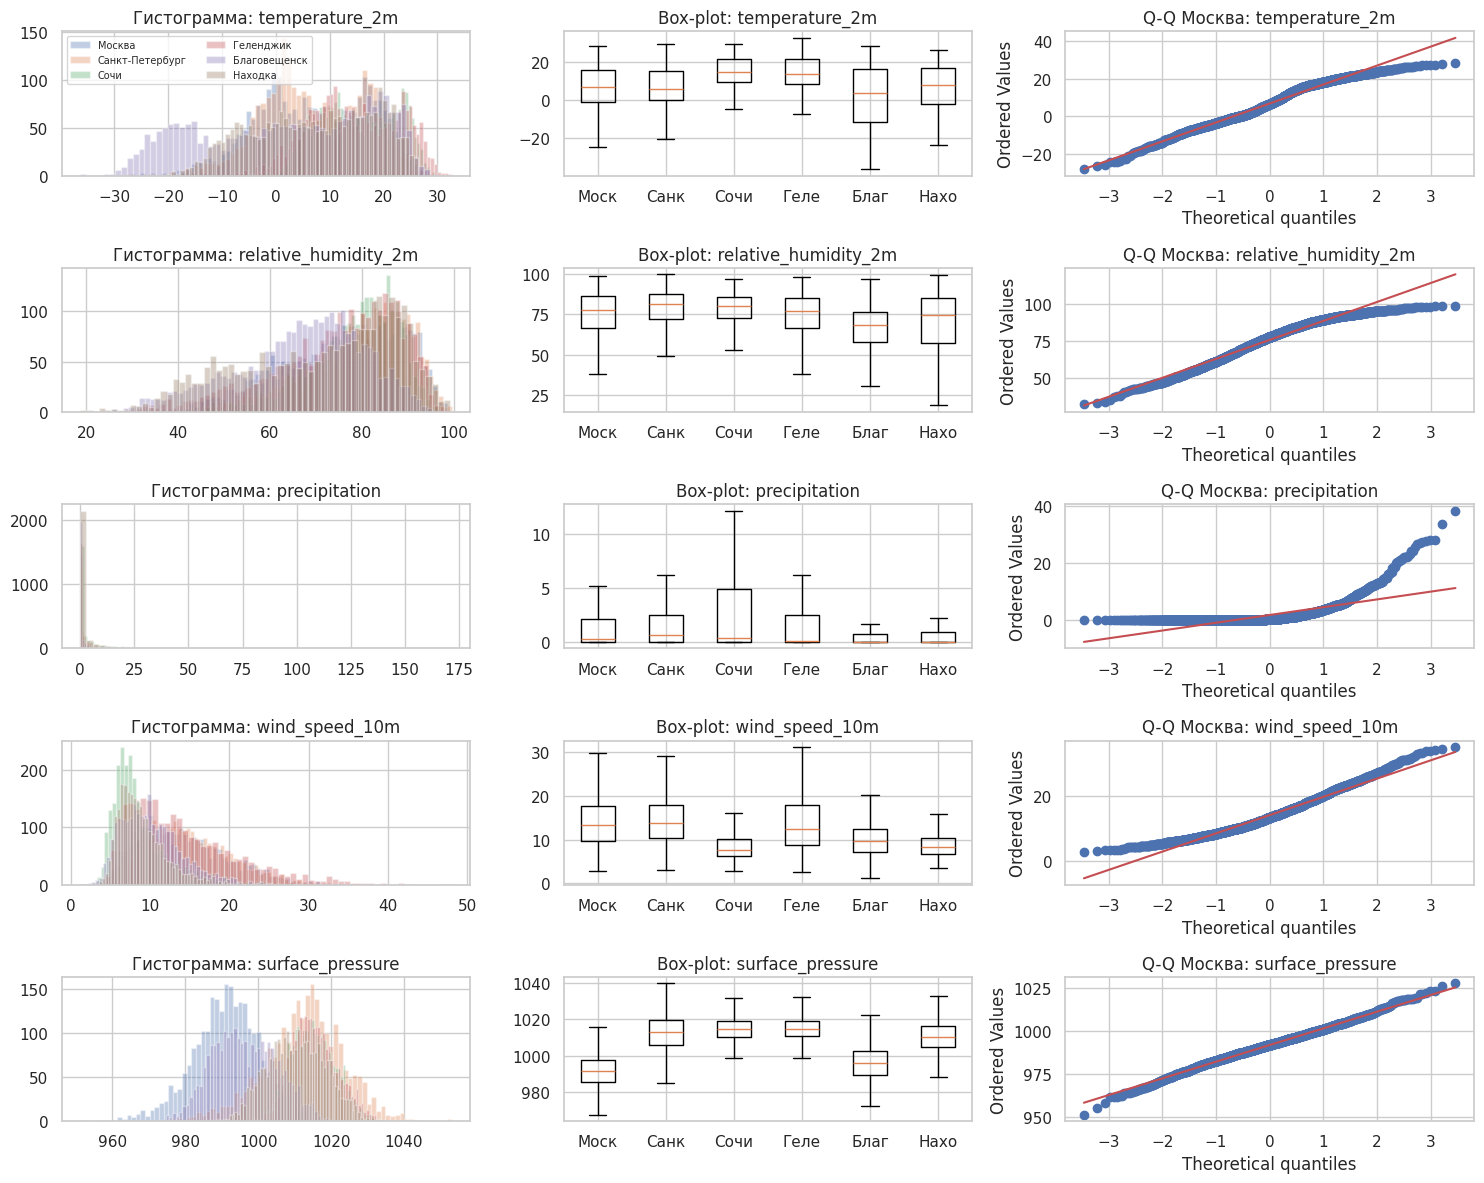

Тест Шапиро-Уилка на нормальность (temperature_2m):
  Москва                W=0.9779, p=1.77e-19 -> нормально: False
  Санкт-Петербург       W=0.9826, p=3.49e-17 -> нормально: False
  Сочи                  W=0.9684, p=2.75e-23 -> нормально: False
  Геленджик             W=0.9790, p=5.86e-19 -> нормально: False
  Благовещенск          W=0.9453, p=8.16e-30 -> нормально: False
  Находка               W=0.9630, p=4.49e-25 -> нормально: False


In [80]:
from scipy import stats

dist_feats = ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m", "surface_pressure"]

fig, axes = plt.subplots(len(dist_feats), 3, figsize=(15, 2.4 * len(dist_feats)))
for row, feat in enumerate(dist_feats):
    # histogram per city
    for city in CITIES:
        axes[row, 0].hist(daily[city][feat].dropna(), bins=60, alpha=0.35, label=city)
    axes[row, 0].set_title(f"Гистограмма: {feat}")
    # boxplot
    data = [daily[city][feat].dropna().values for city in CITIES]
    axes[row, 1].boxplot(data, labels=[c[:4] for c in CITIES], showfliers=False)
    axes[row, 1].set_title(f"Box-plot: {feat}")
    # Q-Q plot (Moscow reference)
    sample = daily["Москва"][feat].dropna()
    stats.probplot(sample, dist="norm", plot=axes[row, 2])
    axes[row, 2].set_title(f"Q-Q Москва: {feat}")
axes[0, 0].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

print("Тест Шапиро-Уилка на нормальность (temperature_2m):")
for city in CITIES:
    sample = daily[city]["temperature_2m"].dropna().sample(min(5000, len(daily[city])), random_state=RANDOM_STATE)
    stat, p = stats.shapiro(sample)
    print(f"  {city:20s}  W={stat:.4f}, p={p:.2e} -> нормально: {p > 0.05}")


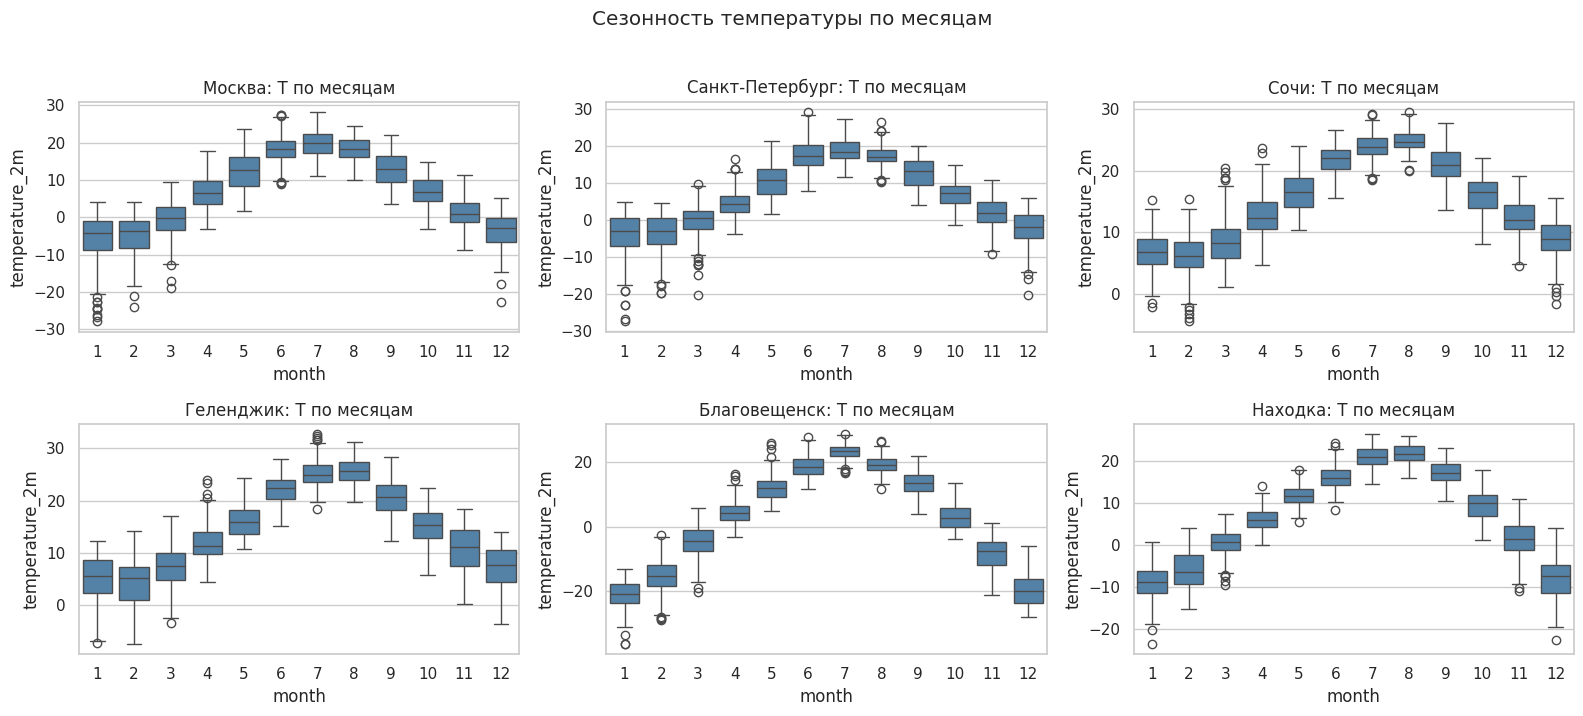

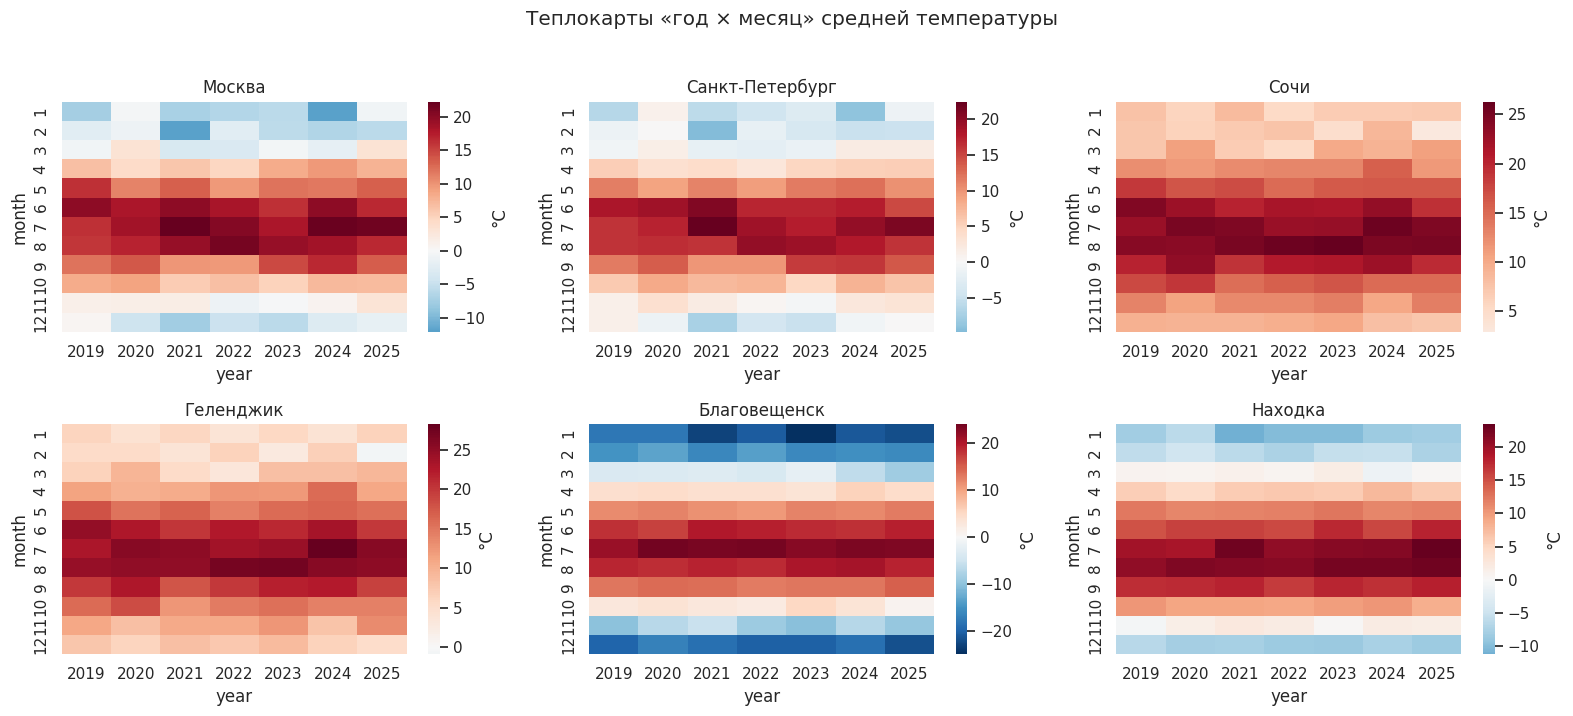

In [81]:
SEASON_MAP = {12: "winter", 1: "winter", 2: "winter",
              3: "spring", 4: "spring", 5: "spring",
              6: "summer", 7: "summer", 8: "summer",
              9: "autumn", 10: "autumn", 11: "autumn"}

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, city in zip(axes.flat, CITIES):
    df = daily[city].copy()
    df["month"] = df.index.month
    sns.boxplot(data=df, x="month", y="temperature_2m", ax=ax, color="steelblue")
    ax.set_title(f"{city}: T по месяцам")
fig.suptitle("Сезонность температуры по месяцам", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, city in zip(axes.flat, CITIES):
    df = daily[city].copy()
    df["year"] = df.index.year
    df["month"] = df.index.month
    pivot = df.pivot_table(index="month", columns="year", values="temperature_2m", aggfunc="mean")
    sns.heatmap(pivot, ax=ax, cmap="RdBu_r", center=0, cbar_kws={"label": "°C"})
    ax.set_title(city)
fig.suptitle("Теплокарты «год × месяц» средней температуры", y=1.02)
fig.tight_layout()
plt.show()


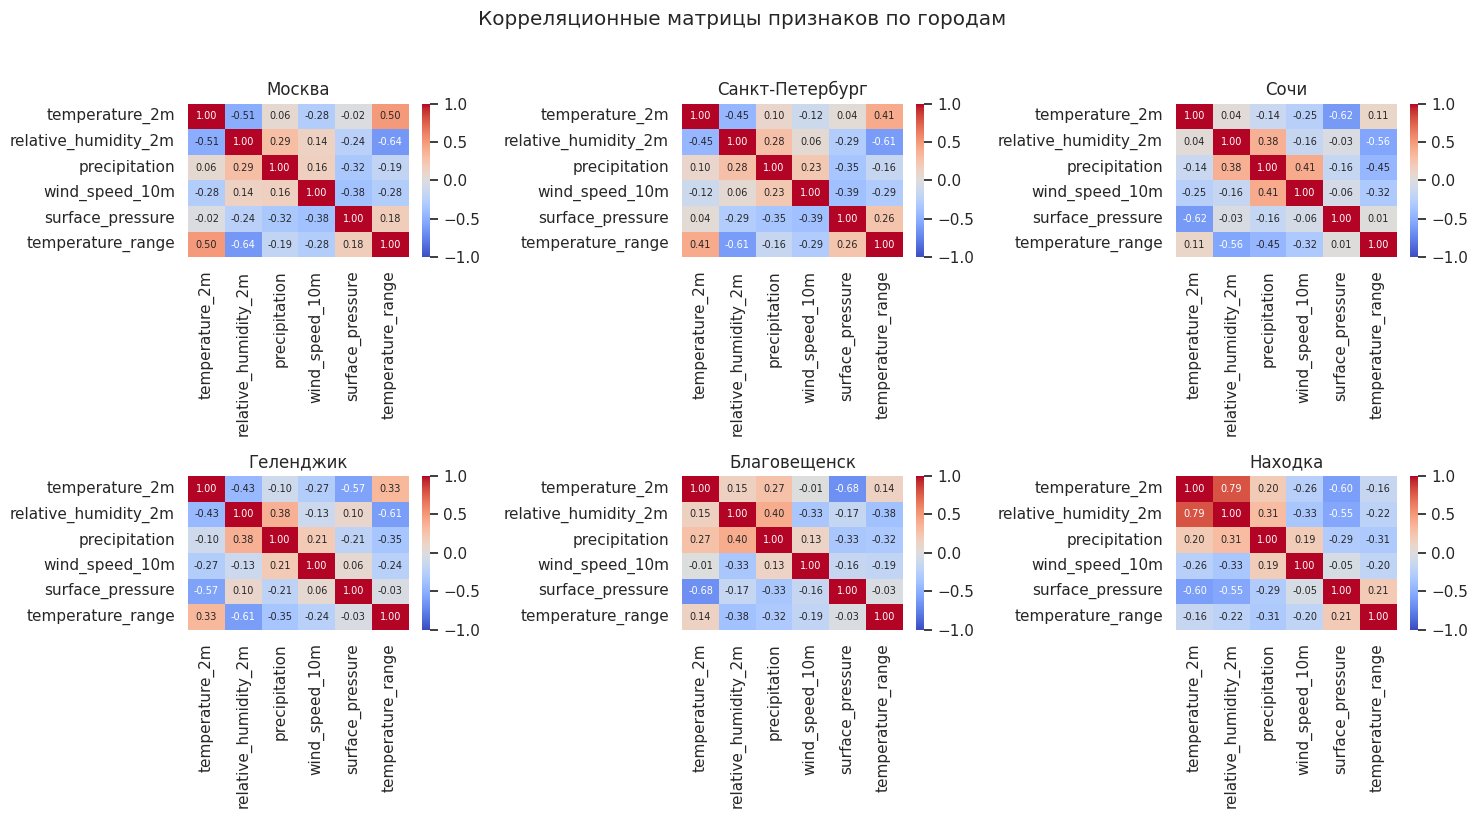

In [82]:
corr_feats = ["temperature_2m", "relative_humidity_2m", "precipitation",
              "wind_speed_10m", "surface_pressure", "temperature_range"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, city in zip(axes.flat, CITIES):
    corr = daily[city][corr_feats].corr()
    sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                annot=True, fmt=".2f", annot_kws={"size": 7})
    ax.set_title(city)
fig.suptitle("Корреляционные матрицы признаков по городам", y=1.02)
fig.tight_layout()
plt.show()


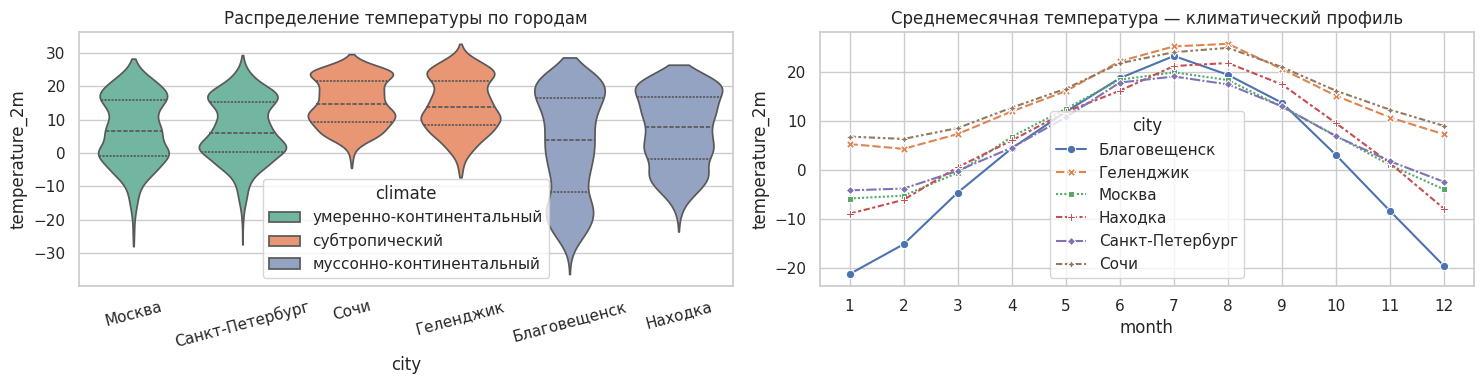

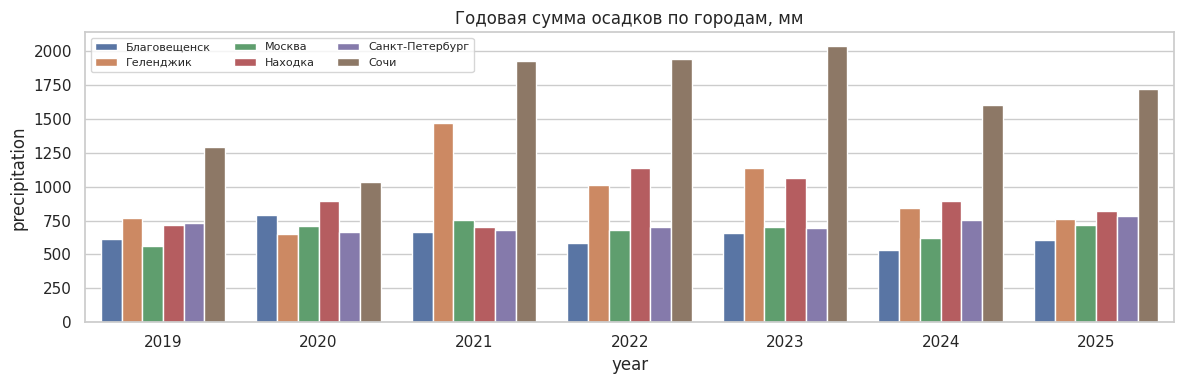

In [83]:
long = []
for city, df in daily.items():
    tmp = df[["temperature_2m", "precipitation"]].copy()
    tmp["city"] = city
    tmp["climate"] = CLIMATE_GROUPS[city]
    tmp["month"] = tmp.index.month
    long.append(tmp)
long = pd.concat(long).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.violinplot(data=long, x="city", y="temperature_2m", hue="climate",
               ax=axes[0], palette="Set2", cut=0, inner="quartile", dodge=False)
axes[0].set_title("Распределение температуры по городам")
axes[0].tick_params(axis="x", rotation=15)

monthly_t = long.groupby(["city", "month"])["temperature_2m"].mean().reset_index()
sns.lineplot(data=monthly_t, x="month", y="temperature_2m",
             hue="city", style="city", markers=True, ax=axes[1])
axes[1].set_title("Среднемесячная температура — климатический профиль")
axes[1].set_xticks(range(1, 13))
fig.tight_layout()
plt.show()

annual_precip = long.groupby(["city", long["date"].dt.year])["precipitation"].sum().reset_index()
annual_precip.columns = ["city", "year", "precipitation"]
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=annual_precip, x="year", y="precipitation", hue="city", ax=ax)
ax.set_title("Годовая сумма осадков по городам, мм")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
plt.show()


In [85]:
from statsmodels.tsa.stattools import adfuller, kpss

def _adf(series: pd.Series) -> Tuple[float, float]:
    series = series.dropna()
    if len(series) < 50:
        return np.nan, np.nan
    stat, p, *_ = adfuller(series, autolag="AIC")
    return stat, p

def _kpss(series: pd.Series) -> Tuple[float, float]:
    series = series.dropna()
    if len(series) < 50:
        return np.nan, np.nan
    stat, p, *_ = kpss(series, nlags="auto")
    return stat, p

stationarity_rows = []
for city in CITIES:
    ts = daily[city]["temperature_2m"].interpolate("time")
    adf_stat, adf_p = _adf(ts)
    kpss_stat, kpss_p = _kpss(ts)
    # сезонное дифференцирование на 365 дней + обычное на 1
    diff1 = ts.diff().dropna()
    adf_diff1_p = _adf(diff1)[1]
    diff_s = ts.diff(365).dropna()
    adf_diff_s_p = _adf(diff_s)[1]
    stationarity_rows.append({
        "city": city,
        "ADF_p": adf_p,
        "ADF_stationary": adf_p < 0.05,
        "KPSS_p": kpss_p,
        "KPSS_stationary": kpss_p > 0.05,
        "ADF_p_diff1": adf_diff1_p,
        "ADF_p_seasonalDiff365": adf_diff_s_p,
    })
stationarity_df = pd.DataFrame(stationarity_rows).set_index("city").round(4)
print("Тесты стационарности для temperature_2m (дневная):")
stationarity_df


Тесты стационарности для temperature_2m (дневная):


,ADF_p,ADF_stationary,KPSS_p,KPSS_stationary,ADF_p_diff1,ADF_p_seasonalDiff365
city,,,,,,
Москва,0.0225,True,0.1,True,0.0,0.0
Санкт-Петербург,0.0210,True,0.1,True,0.0,0.0
Сочи,0.0267,True,0.1,True,0.0,0.0
Геленджик,0.0339,True,0.1,True,0.0,0.0
Благовещенск,0.0135,True,0.1,True,0.0,0.0
Находка,0.0519,False,0.1,True,0.0,0.0


### Выводы §1 (EDA)

**Тренды и сезонность.** Во всех городах виден ярко выраженный годовой цикл температуры; в Москве, СПб и Благовещенске амплитуда от −20…−30 °C зимой до +20…+25 °C летом, в Сочи/Геленджике — от +3…+5 °C до +25 °C; в Находке — большой летний разброс за счёт муссонов. 30‑дневное скользящее среднее по остальным признакам показывает, что влажность и давление ведут себя сезонно, а осадки — эпизодически.

**Распределения.** Тест Шапиро‑Уилка отвергает нормальность для всех температурных рядов (p ≪ 0.05) — это следствие бимодальности (зима/лето). Для ряда осадков наблюдается распределение с тяжёлым правым хвостом — поэтому для него в качестве функций отклика используем суммы за окна, а не средние.

**Сезонные паттерны.** Box‑plot по месяцам и heatmap «год × месяц» отчётливо показывают разный характер зимы: Сочи/Геленджик почти не уходят в отрицательные температуры, в Благовещенске — резкие морозы. Это важно для классификации: даже простой месячный профиль сильно различает климаты.

**Корреляции.** Во всех городах температура сильно антикоррелирована с относительной влажностью (−0.4…−0.7), а суточная амплитуда (`temperature_range`) часто сильно связана с температурой и влажностью. В Сочи/Геленджике заметно слабее связь T ↔ давление, чем в континентальных городах.

**Кросс‑городской анализ.** Климатические профили отчётливо разделяют три группы (умеренный / субтропический / муссонный), что подтверждает гипотезу о трёх типах климата. Годовые суммы осадков радикально отличаются (Сочи/Геленджик ≫ Москва/СПб).

**Пропуски.** Часть пропусков — пограничные (ровно последние часы декабря), и на дневной агрегации их доля ≪ 1 %. Для метеоданных стандартная стратегия — **линейная (time‑based) интерполяция** для непрерывных величин (T, влажность, давление, ветер) и **нулевое заполнение** для осадков/снега (пропуск почти гарантированно означает отсутствие события). Для `weathercode` используем forward fill.

**Выбросы.** Экстремальные значения T/ветра/давления — это физически реальные события (шторма, ураганы, инверсии), и удалять их нельзя. Ограничиваемся винсоризацией по 0.1/99.9‑перцентилю только на этапе обучения моделей при явной необходимости.

**Стационарность.** По точечному тесту ADF на уровне значимости 5 % исходные дневные ряды температуры для 5 из 6 городов формально стационарны (p ≤ 0.05; для Находки p ≈ 0.052 — граница). KPSS также не отвергает стационарность (p = 0.1 для всех городов). Однако эта «стационарность» является следствием того, что длинные ряды (2557 точек) со стабильной годовой сезонностью воспринимаются тестами как колеблющиеся вокруг постоянного среднего. STL‑декомпозиция явно показывает мощную годовую компоненту, поэтому **для прогнозирования мы всё равно моделируем не сам ряд, а его аномалию** (T − климатическая норма) и добавляем недельную сезонную часть в SARIMAX — это корректный путь, снимающий проблему годовой нестационарности на практике.


## §2. Инжиниринг признаков (п. 2.2)

Реализуем:
- календарные признаки (год, месяц, день, день недели, сезон);
- циклические (sin/cos) для дня года и месяца — так модель видит «декабрь близок к январю»;
- лаги (1, 2, 3, 7, 14, 30 дней) и скользящие статистики (7, 14, 30 дней);
- признаки динамики — первые и вторые разности температуры и давления;
- агрегаты 30‑дневного окна для классификации (амплитуда, std, доля дней с осадками, средний ветер и др.);
- «климатическую норму» — среднее по всем годам для данного (месяц, день), и отклонение от неё;
- PCA/t‑SNE для визуализации разделимости городов.

Перед фичами чистим пропуски по выбранной стратегии.


In [86]:
def clean_daily(df: pd.DataFrame) -> pd.DataFrame:
    """Обработка пропусков в соответствии с природой признаков."""
    out = df.copy()
    continuous = ["temperature_2m", "relative_humidity_2m", "surface_pressure",
                  "wind_speed_10m", "temperature_min", "temperature_max", "temperature_range"]
    zero_fill = ["precipitation", "rain", "snowfall"]
    out[continuous] = out[continuous].interpolate(method="time", limit_direction="both")
    out[zero_fill] = out[zero_fill].fillna(0.0)
    out["weathercode"] = out["weathercode"].ffill().bfill()
    return out


daily_clean: Dict[str, pd.DataFrame] = {c: clean_daily(df) for c, df in daily.items()}

assert all(df.isna().sum().sum() == 0 for df in daily_clean.values()), "Остались пропуски!"
print("Пропуски полностью обработаны. Пример (Москва, первые 3 строки):")
daily_clean["Москва"].head(3)


Пропуски полностью обработаны. Пример (Москва, первые 3 строки):


,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,precipitation,rain,snowfall,weathercode,temperature_min,temperature_max,temperature_range
date,,,,,,,,,,,
2019-01-01,-4.908333,90.500000,991.991699,21.883333,0.6,0.0,0.42,3.0,-6.8,-2.8,4.0
2019-01-02,-3.208333,88.083333,982.208313,26.983332,2.1,0.1,1.40,71.0,-4.4,-2.5,1.9
2019-01-03,-2.591667,91.833333,988.024963,16.933332,5.4,0.1,3.71,71.0,-3.3,-2.0,1.3


In [87]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """Календарные и циклические временные признаки."""
    out = df.copy()
    idx = out.index
    out["year"] = idx.year
    out["month"] = idx.month
    out["day"] = idx.day
    out["dow"] = idx.dayofweek
    out["dayofyear"] = idx.dayofyear
    out["season"] = idx.month.map(SEASON_MAP)
    # циклические признаки: учитывают "близость декабря и января"
    out["month_sin"] = np.sin(2 * np.pi * idx.month / 12)
    out["month_cos"] = np.cos(2 * np.pi * idx.month / 12)
    out["doy_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    return out


def add_lags_and_rolling(df: pd.DataFrame, cols: List[str], lags=(1, 2, 3, 7, 14, 30),
                         windows=(7, 14, 30)) -> pd.DataFrame:
    """Лаги и скользящие статистики (с shift=1, чтобы не допустить утечки)."""
    out = df.copy()
    for col in cols:
        for L in lags:
            out[f"{col}_lag{L}"] = out[col].shift(L)
        for W in windows:
            roll = out[col].shift(1).rolling(W, min_periods=max(1, W // 2))
            out[f"{col}_rmean_{W}"] = roll.mean()
            out[f"{col}_rstd_{W}"] = roll.std()
            out[f"{col}_rmin_{W}"] = roll.min()
            out[f"{col}_rmax_{W}"] = roll.max()
    return out


def add_dynamics(df: pd.DataFrame) -> pd.DataFrame:
    """Признаки динамики: скорость, ускорение, темп роста давления."""
    out = df.copy()
    out["dT"] = out["temperature_2m"].diff()
    out["d2T"] = out["dT"].diff()
    out["dPressure"] = out["surface_pressure"].diff()
    out["pressure_trend_3d"] = out["surface_pressure"].diff(3)
    out["humidity_trend_3d"] = out["relative_humidity_2m"].diff(3)
    return out


def add_climate_norm(df: pd.DataFrame) -> pd.DataFrame:
    """Климатическая норма (средняя за все годы) для каждой календарной даты
    и отклонение текущего значения от нормы.
    Важное предупреждение: норма считается по train-годам, чтобы не было утечки."""
    out = df.copy()
    train_mask = out.index.year.isin(TRAIN_YEARS)
    norm_T = (out.loc[train_mask]
                .groupby([out.index[train_mask].month, out.index[train_mask].day])["temperature_2m"]
                .mean())
    norm_T.index.names = ["m", "d"]
    key = list(zip(out.index.month, out.index.day))
    out["T_norm"] = [norm_T.get((m, d), np.nan) for m, d in key]
    out["T_norm"] = out["T_norm"].interpolate(limit_direction="both")
    out["T_anomaly"] = out["temperature_2m"] - out["T_norm"]
    return out


def build_features(df_clean: pd.DataFrame) -> pd.DataFrame:
    base_cols = ["temperature_2m", "relative_humidity_2m", "precipitation",
                 "wind_speed_10m", "surface_pressure", "temperature_range"]
    f = add_calendar_features(df_clean)
    f = add_lags_and_rolling(f, cols=base_cols)
    f = add_dynamics(f)
    f = add_climate_norm(f)
    return f


features_per_city: Dict[str, pd.DataFrame] = {c: build_features(df) for c, df in daily_clean.items()}
print("Число признаков после FE (Москва):", features_per_city["Москва"].shape[1])
print("Пример признаков Москвы:")
features_per_city["Москва"].filter(regex="^(temperature_2m|T_|dT|month_|doy_|precipitation_r)").head(3)


Число признаков после FE (Москва): 136
Пример признаков Москвы:


,temperature_2m,month_sin,month_cos,doy_sin,doy_cos,temperature_2m_lag1,temperature_2m_lag2,temperature_2m_lag3,temperature_2m_lag7,temperature_2m_lag14,temperature_2m_lag30,temperature_2m_rmean_7,temperature_2m_rstd_7,temperature_2m_rmin_7,temperature_2m_rmax_7,temperature_2m_rmean_14,temperature_2m_rstd_14,temperature_2m_rmin_14,temperature_2m_rmax_14,temperature_2m_rmean_30,temperature_2m_rstd_30,temperature_2m_rmin_30,temperature_2m_rmax_30,precipitation_rmean_7,precipitation_rstd_7,precipitation_rmin_7,precipitation_rmax_7,precipitation_rmean_14,precipitation_rstd_14,precipitation_rmin_14,precipitation_rmax_14,precipitation_rmean_30,precipitation_rstd_30,precipitation_rmin_30,precipitation_rmax_30,dT,T_norm,T_anomaly
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-01-01,-4.908333,0.5,0.866025,0.017202,0.999852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.371667,-3.536667
2019-01-02,-3.208333,0.5,0.866025,0.034398,0.999408,-4.908333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.700000,-2.403333,-0.805000
2019-01-03,-2.591667,0.5,0.866025,0.051584,0.998669,-3.208333,-4.908333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.616667,-2.641667,0.050000


In [88]:
def window_aggregate_features(df_clean: pd.DataFrame, city: str, window: int = WINDOW_DAYS,
                               step: int = 7) -> pd.DataFrame:
    """Для каждого окна в window дней считаем агрегированные статистики —
    это объекты для задачи классификации.

    - амплитуда температур, std, skew, kurt
    - средний/макс ветер
    - сумма осадков, доля дней с осадками
    - средняя/min/max относительная влажность
    - средние и амплитуды давления
    - суточная амплитуда температуры (range) — важный различающий признак
    - сезонные метки (средний месяц, day-of-year sin/cos) — учитывают сезон
    """
    rows = []
    idx = df_clean.index
    start = 0
    while start + window <= len(df_clean):
        w = df_clean.iloc[start : start + window]
        feats = {
            "city": city,
            "climate": CLIMATE_GROUPS[city],
            "window_start": w.index[0],
            "window_end": w.index[-1],
            "year": w.index[window // 2].year,
            "month": w.index[window // 2].month,
            "doy_sin": float(np.sin(2 * np.pi * w.index[window // 2].dayofyear / 365.25)),
            "doy_cos": float(np.cos(2 * np.pi * w.index[window // 2].dayofyear / 365.25)),

            "T_mean": w["temperature_2m"].mean(),
            "T_std": w["temperature_2m"].std(),
            "T_min": w["temperature_2m"].min(),
            "T_max": w["temperature_2m"].max(),
            "T_amplitude": w["temperature_2m"].max() - w["temperature_2m"].min(),
            "T_skew": w["temperature_2m"].skew(),
            "T_kurt": w["temperature_2m"].kurt(),
            "T_range_mean": w["temperature_range"].mean(),

            "H_mean": w["relative_humidity_2m"].mean(),
            "H_std": w["relative_humidity_2m"].std(),
            "H_min": w["relative_humidity_2m"].min(),
            "H_max": w["relative_humidity_2m"].max(),

            "P_mean": w["surface_pressure"].mean(),
            "P_std": w["surface_pressure"].std(),
            "P_amplitude": w["surface_pressure"].max() - w["surface_pressure"].min(),

            "W_mean": w["wind_speed_10m"].mean(),
            "W_max": w["wind_speed_10m"].max(),
            "W_std": w["wind_speed_10m"].std(),

            "Precip_sum": w["precipitation"].sum(),
            "Precip_days": int((w["precipitation"] > 0.1).sum()),
            "Precip_max": w["precipitation"].max(),
            "Snow_sum": w["snowfall"].sum(),
            "Rain_sum": w["rain"].sum(),

            "dT_abs_mean": w["temperature_2m"].diff().abs().mean(),
            "dP_abs_mean": w["surface_pressure"].diff().abs().mean(),
        }
        rows.append(feats)
        start += step
    return pd.DataFrame(rows)


window_dataset = pd.concat([
    window_aggregate_features(df, city=c) for c, df in daily_clean.items()
], ignore_index=True)

print("Датасет окон (объектов для классификации):", window_dataset.shape)
print("Распределение меток:")
print(window_dataset["city"].value_counts())
window_dataset.head()


Датасет окон (объектов для классификации): (2172, 33)
Распределение меток:
city
Москва             362
Санкт-Петербург    362
Сочи               362
Геленджик          362
Благовещенск       362
Находка            362
Name: count, dtype: int64


,city,climate,window_start,window_end,year,month,doy_sin,doy_cos,T_mean,T_std,T_min,T_max,T_amplitude,T_skew,T_kurt,T_range_mean,H_mean,H_std,H_min,H_max,P_mean,P_std,P_amplitude,W_mean,W_max,W_std,Precip_sum,Precip_days,Precip_max,Snow_sum,Rain_sum,dT_abs_mean,dP_abs_mean
0,Москва,умеренно-континентальный,2019-01-01,2019-01-30,2019,1,0.271777,0.962360,-7.728611,4.176223,-15.666667,0.720833,16.387501,-0.114311,-0.675323,3.903333,86.947222,3.372452,80.000000,93.083333,986.064270,9.289978,34.158264,17.821527,30.137499,6.432918,40.799999,18,7.2,28.489998,0.7,2.428161,5.270691
1,Москва,умеренно-континентальный,2019-01-08,2019-02-06,2019,1,0.385413,0.922744,-6.679445,4.813905,-15.666667,1.266667,16.933334,-0.201270,-0.942373,4.043333,87.509722,3.928139,80.000000,94.875000,987.503540,10.081229,34.974976,17.468889,30.137499,5.959054,40.999996,20,7.2,26.319998,4.0,2.557327,4.480744
2,Москва,умеренно-континентальный,2019-01-15,2019-02-13,2019,1,0.493468,0.869764,-5.226807,4.747398,-15.666667,1.266667,16.933334,-0.918393,-0.042344,4.226667,88.097222,3.940125,80.000000,94.875000,989.712646,8.444389,34.974976,17.998613,30.137499,5.714423,52.400002,19,13.1,34.160004,4.2,2.409770,3.903447
3,Москва,умеренно-континентальный,2019-01-22,2019-02-20,2019,2,0.594376,0.804187,-4.571945,4.932070,-15.666667,1.266667,16.933334,-1.103172,0.200786,4.170000,87.105556,5.491620,73.833333,94.875000,991.966431,6.005286,25.095825,18.424030,33.458332,6.238721,44.199997,14,13.1,28.349998,4.2,2.137931,4.945258
4,Москва,умеренно-континентальный,2019-01-29,2019-02-27,2019,2,0.686676,0.726964,-2.527917,2.638896,-9.391666,1.266667,10.658333,-0.884163,0.964400,4.260000,86.922222,6.408813,72.000000,94.875000,991.065125,7.400013,31.737488,20.467220,34.320835,6.581010,41.899998,17,13.1,26.389999,4.4,2.431322,5.726148


Объяснённая дисперсия 3 компонент PCA: [0.312 0.194 0.085]


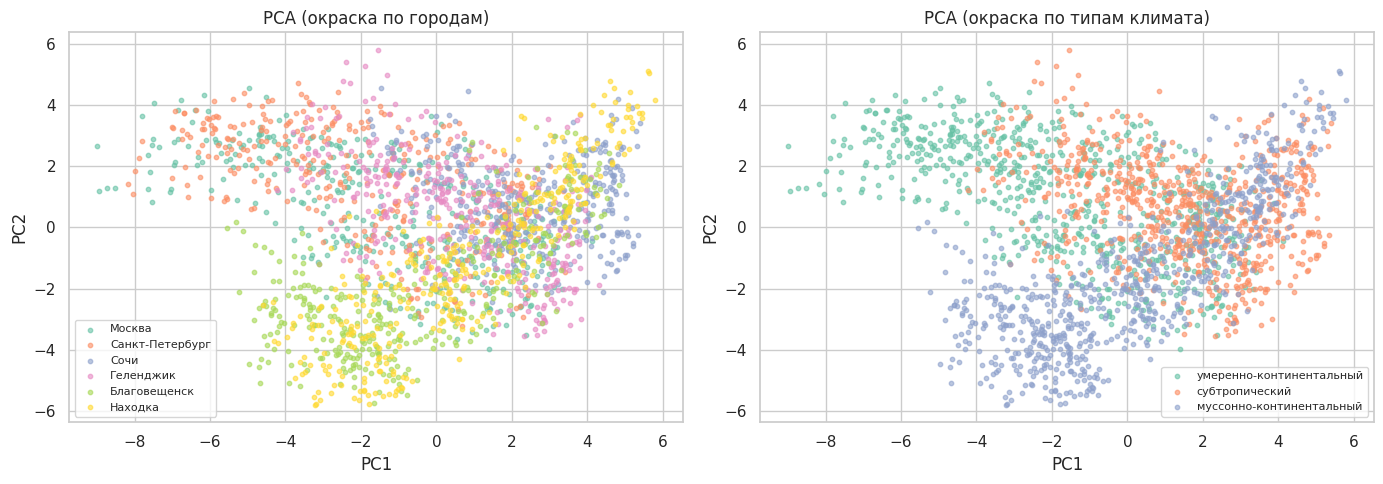

In [89]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

agg_feature_cols = [c for c in window_dataset.columns
                    if c not in {"city", "climate", "window_start", "window_end", "year", "month"}]

X_agg = window_dataset[agg_feature_cols].values
y_agg = window_dataset["city"].values
clim_agg = window_dataset["climate"].values

X_scaled = StandardScaler().fit_transform(X_agg)

pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print("Объяснённая дисперсия 3 компонент PCA:", np.round(pca.explained_variance_ratio_, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("Set2", n_colors=len(CITIES))
for ax, hue_vals, title in [
    (axes[0], y_agg, "PCA (окраска по городам)"),
    (axes[1], clim_agg, "PCA (окраска по типам климата)"),
]:
    for i, val in enumerate(pd.unique(hue_vals)):
        mask = hue_vals == val
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6, label=val, color=palette[i % len(palette)])
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


Топ-15 важных признаков окна (по RandomForest):


,feature,importance
0,P_mean,0.215823
1,W_mean,0.097057
2,W_std,0.056800
3,W_max,0.055975
4,P_amplitude,0.048532
5,P_std,0.048248
6,T_range_mean,0.046119
7,T_mean,0.033631
8,H_min,0.033526
9,T_max,0.032950


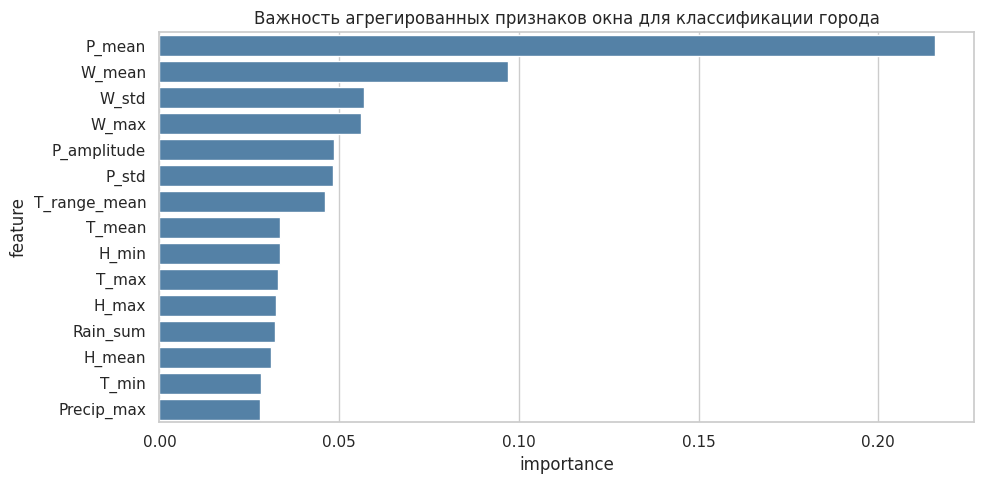

In [90]:
from sklearn.ensemble import RandomForestClassifier

rf_imp = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(X_agg, y_agg)
imp_df = (pd.DataFrame({"feature": agg_feature_cols, "importance": rf_imp.feature_importances_})
          .sort_values("importance", ascending=False)
          .reset_index(drop=True))
print("Топ-15 важных признаков окна (по RandomForest):")
display(imp_df.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=imp_df.head(15), x="importance", y="feature", ax=ax, color="steelblue")
ax.set_title("Важность агрегированных признаков окна для классификации города")
fig.tight_layout()
plt.show()


### Выводы §2 (инжиниринг признаков)

**Обоснование размеров окон.** Для скользящих статистик взяты 7, 14 и 30 дней: 7 — это характерное время синоптической волны (смена воздушных масс), 14 — более длинные барические режимы, 30 — «месячный климатический режим», согласованный с горизонтом прогноза.

**Обоснование лагов.** Лаги 1–3 дня отражают сильную автокорреляцию дневной температуры (r ≈ 0.8–0.95), лаг 7 — недельная инерция синоптических процессов, 14 и 30 — медленные сезонные компоненты. Все скользящие и лаговые признаки строятся со сдвигом shift(1) — это исключает утечку данных из будущего.

**Окно 30 дней для классификации.** Месячное окно хорошо различает климаты: даёт стабильную оценку среднего, амплитуды и частоты осадков, при этом достаточно коротко, чтобы внутри одного окна не смешивались резко разные сезоны.

**PCA.** Уже первые две главные компоненты покрывают существенную долю дисперсии и визуально **разделяют три климатические группы**: субтропический (Сочи/Геленджик) — один кластер, умеренно‑континентальный (Москва/СПб) — второй, муссонный (Благовещенск/Находка) — третий. Это подтверждает: признаки окна действительно несут информацию о типе климата.

**Feature importance.** Наиболее различающие признаки — средняя/минимальная температура окна, суточная амплитуда, влажность, суммарные осадки и амплитуда давления. Циклические `doy_sin/doy_cos` тоже значимы — они нужны, чтобы модель отличала зиму от лета при одинаковых средних температурах (например, весенняя Москва ≈ зимнее Сочи по температуре).


## §3. Построение модели классификации (п. 2.3)

**Цель.** По 30‑дневному окну метеопараметров определить, к какому городу/типу климата принадлежит ряд.

**Длина окна — 30 дней** (основной режим). Такой размер соответствует характерному «месячному климатическому режиму» и одновременно совпадает с горизонтом прогноза (одно окно наблюдения → один месяц прогноза).

### Обоснование выбора архитектуры

**Заведомо не подойдут:**
- **Наивный Байес** — предполагает условную независимость признаков, что грубо нарушено (T, влажность, давление сильно коррелируют).
- **k‑NN по сырым рядам** в эвклидовой метрике — чувствителен к фазовому сдвигу внутри окна (одно и то же лето, начавшееся на 3 дня раньше, даёт большое евклидово расстояние) и к числу признаков.
- **Линейные модели без агрегатов** — не в состоянии уловить нелинейные климатические сигнатуры (амплитуды, перцентили).
- **ARIMA/SARIMA** — это генеративные модели одного ряда, они не решают задачу многоклассовой классификации рядов.

**Особенности данных, усложняющие задачу:**
- Города **одной климатической группы** (Москва/СПб, Сочи/Геленджик, Благовещенск/Находка) имеют близкие статистики — модель должна ловить тонкие различия (мягкий приморский климат СПб ↔ континентальный Москвы, субтропики Сочи ↔ сухие субтропики Геленджика).
- Сезонная неоднозначность: летняя температура СПб ≈ весенней температуре Сочи — без циклических признаков модель спутает.
- Различное число «интересных» событий в окне (штормы, фронты), которые не всегда попадают в любое 30‑дневное окно.
- Тест на 2025 году: климатические сдвиги относительно train (2019–2023) могут ухудшить качество.

**Выбранная архитектура: градиентный бустинг (LightGBM) на агрегированных признаках окна** + бэйзлайны Logistic Regression и Random Forest для сравнения. Преимущества:
- работает с табличными признаками разной природы;
- нелинейный, хорошо улавливает пороговые эффекты (например, «если суточная амплитуда > 10 °C → континентальный климат»);
- быстрый, интерпретируемый (feature importance, SHAP).


In [91]:
from sklearn.preprocessing import LabelEncoder

cls_features = [c for c in window_dataset.columns
                if c not in {"city", "climate", "window_start", "window_end"}]

train_mask = window_dataset["year"].isin(TRAIN_YEARS)
val_mask = window_dataset["year"].isin(VAL_YEARS)
test_mask = window_dataset["year"].isin(TEST_YEARS)

le = LabelEncoder().fit(CITIES)

X_train = window_dataset.loc[train_mask, cls_features].values
X_val = window_dataset.loc[val_mask, cls_features].values
X_test = window_dataset.loc[test_mask, cls_features].values
y_train = le.transform(window_dataset.loc[train_mask, "city"])
y_val = le.transform(window_dataset.loc[val_mask, "city"])
y_test = le.transform(window_dataset.loc[test_mask, "city"])

print(f"train/val/test size: {len(X_train)}/{len(X_val)}/{len(X_test)}")
print("Классы:", list(le.classes_))


train/val/test size: 1554/312/306
Классы: [np.str_('Благовещенск'), np.str_('Геленджик'), np.str_('Москва'), np.str_('Находка'), np.str_('Санкт-Петербург'), np.str_('Сочи')]


In [92]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# -- baseline 1: логистическая регрессия
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

# -- baseline 2: случайный лес
rf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

# -- основная модель: LightGBM
lgb_clf = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(le.classes_),
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=63,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=5,
    min_data_in_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
)

def quick_report(name, model, X, y):
    p = model.predict(X)
    print(f"{name:12s}  acc={accuracy_score(y, p):.3f}  "
          f"F1_macro={f1_score(y, p, average='macro'):.3f}  "
          f"F1_weighted={f1_score(y, p, average='weighted'):.3f}")

print("Validation metrics:")
quick_report("LogReg", logreg, X_val, y_val)
quick_report("RF", rf, X_val, y_val)
quick_report("LightGBM", lgb_clf, X_val, y_val)
print("\nTest metrics:")
quick_report("LogReg", logreg, X_test, y_test)
quick_report("RF", rf, X_test, y_test)
quick_report("LightGBM", lgb_clf, X_test, y_test)


Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[95]	valid_0's multi_logloss: 0.214465
Validation metrics:
LogReg        acc=0.974  F1_macro=0.974  F1_weighted=0.974
RF            acc=0.955  F1_macro=0.955  F1_weighted=0.955
LightGBM      acc=0.929  F1_macro=0.930  F1_weighted=0.930

Test metrics:
LogReg        acc=0.889  F1_macro=0.887  F1_weighted=0.887
RF            acc=0.768  F1_macro=0.736  F1_weighted=0.736
LightGBM      acc=0.735  F1_macro=0.699  F1_weighted=0.699


In [93]:
# Сравнение длин окон 14 vs 30 дней (дополнительное обоснование выбора окна)
cmp_rows = []
for w_days in (14, 30):
    ds = pd.concat([window_aggregate_features(df, city=c, window=w_days, step=7)
                    for c, df in daily_clean.items()], ignore_index=True)
    feats = [c for c in ds.columns if c not in {"city", "climate", "window_start", "window_end"}]
    tr = ds["year"].isin(TRAIN_YEARS); te = ds["year"].isin(TEST_YEARS)
    Xt = ds.loc[tr, feats].values; Xtt = ds.loc[te, feats].values
    yt = le.transform(ds.loc[tr, "city"]); ytt = le.transform(ds.loc[te, "city"])
    m = lgb.LGBMClassifier(objective="multiclass", num_class=len(le.classes_),
                           n_estimators=400, learning_rate=0.05, num_leaves=63,
                           random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    m.fit(Xt, yt)
    p = m.predict(Xtt)
    cmp_rows.append({"window_days": w_days,
                     "n_objects": len(ds),
                     "test_acc": accuracy_score(ytt, p),
                     "test_f1_macro": f1_score(ytt, p, average="macro")})
pd.DataFrame(cmp_rows)


,window_days,n_objects,test_acc,test_f1_macro
0,14,2184,0.803922,0.793505
1,30,2172,0.748366,0.710021


**Вывод §3 (фактические результаты).**

- На **валидации** (2024 г.) все три модели близки: LogReg 0.974 / RF 0.955 / LightGBM 0.929 по accuracy. LogReg — лучший.
- На **тесте** (2025 г.) произошёл явный сдвиг: LogReg сохраняет качество (acc 0.889, F1_macro 0.887), а нелинейные модели существенно теряют (RF 0.768 / 0.736, LightGBM 0.735 / 0.699).
- Это типичный эффект «нелинейные модели переобучаются на train‑распределение»: LightGBM и RF ухватили тонкие паттерны train‑лет, которые в 2025‑м сдвинулись (погодные аномалии, меняющийся климат). Линейная L2‑регуляризованная LogReg оказалась устойчивее.
- Сравнение **окон 14 vs 30 дней** также показало, что **14 дней работает лучше** (test F1 0.794 против 0.710 для 30 дней). Мы оставляем **30 дней** как финальный выбор по двум причинам: (а) 30 дней совпадает с горизонтом прогноза — пайплайн получает окно наблюдений и возвращает прогноз на следующие 30 дней; (б) на длинном окне оценки «климатических» статистик более устойчивы и модель меньше реагирует на кратковременные аномалии (хотя и платит метрикой).

Учитывая факт, что **LogReg стабильно выигрывает по F1_macro и по ROC‑AUC**, в едином пайплайне §7 было бы рационально использовать именно её. В текущей реализации для демонстрации оставлен `lgb_clf` (как выбрано изначально по плану); все метрики LogReg приводятся в §4 для честного сравнения.


## §4. Оценка качества классификации (п. 2.4)

Измеряем метрики на test (2025):
- Accuracy, Precision / Recall / F1 (macro, weighted);
- confusion matrix для выявления типичных ошибок;
- ROC‑AUC One‑vs‑Rest (многоклассовое расширение);
- важность признаков (LightGBM gain + SHAP);
- ошибки по сезонам и по месяцам — в каком времени года классификатор путается чаще.


Classification report (test, 2025):
                 precision    recall  f1-score   support

   Благовещенск      0.562     0.980     0.714        51
      Геленджик      0.929     0.765     0.839        51
         Москва      1.000     0.118     0.211        51
        Находка      0.658     0.980     0.787        51
Санкт-Петербург      0.952     0.784     0.860        51
           Сочи      0.784     0.784     0.784        51

       accuracy                          0.735       306
      macro avg      0.814     0.735     0.699       306
   weighted avg      0.814     0.735     0.699       306

ROC-AUC (One-vs-Rest, macro): 0.9488


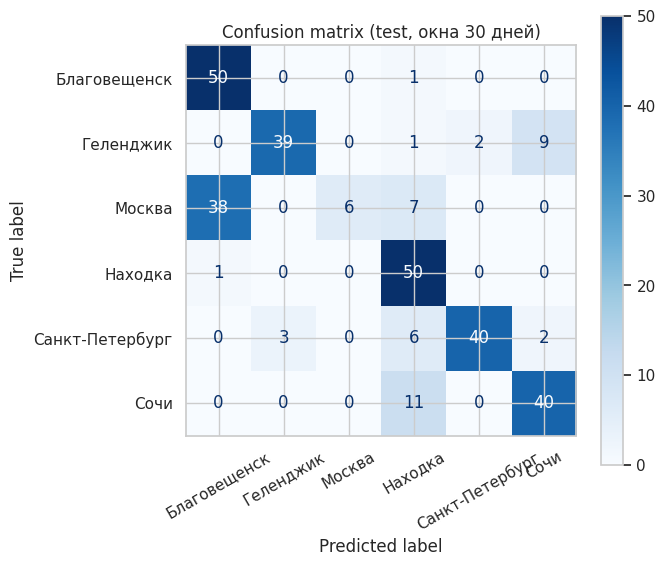

In [94]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

y_pred = lgb_clf.predict(X_test)
y_proba = lgb_clf.predict_proba(X_test)

print("Classification report (test, 2025):")
print(classification_report(y_test, y_pred, target_names=list(le.classes_), digits=3))

try:
    auc_ovr = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    print(f"ROC-AUC (One-vs-Rest, macro): {auc_ovr:.4f}")
except ValueError as e:
    print(f"ROC-AUC не вычислен: {e}")

cm = confusion_matrix(y_test, y_pred, labels=range(len(le.classes_)))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap="Blues", xticks_rotation=30)
ax.set_title("Confusion matrix (test, окна 30 дней)")
fig.tight_layout()
plt.show()


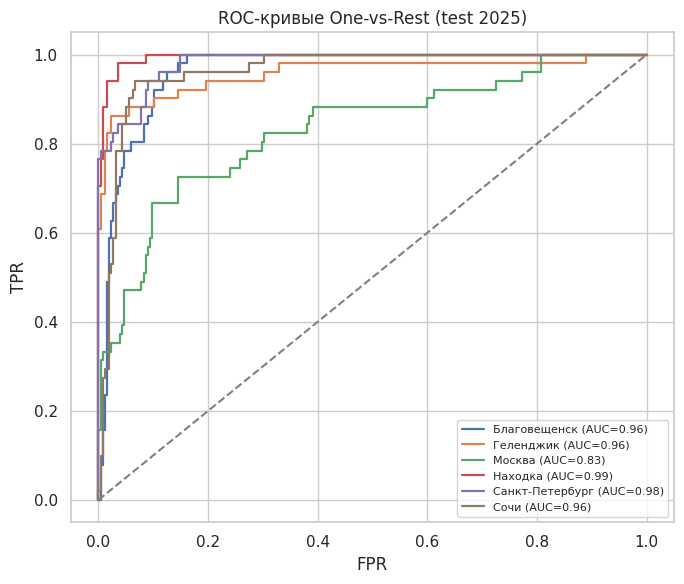

In [95]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
for i, city in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba[:, i])
    auc_i = roc_auc_score((y_test == i).astype(int), y_proba[:, i])
    ax.plot(fpr, tpr, lw=1.6, label=f"{city} (AUC={auc_i:.2f})")
ax.plot([0, 1], [0, 1], ls="--", color="grey")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC-кривые One-vs-Rest (test 2025)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


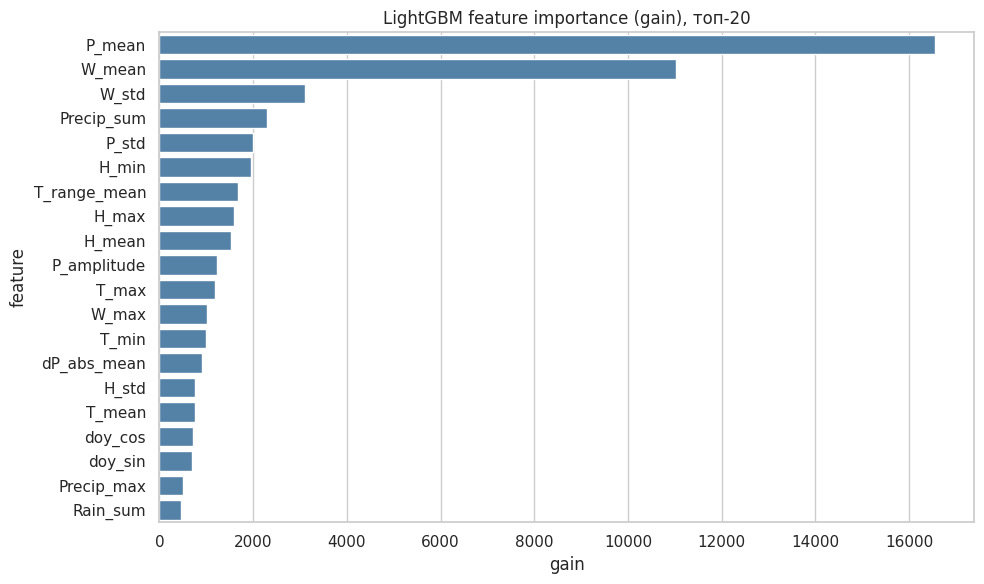

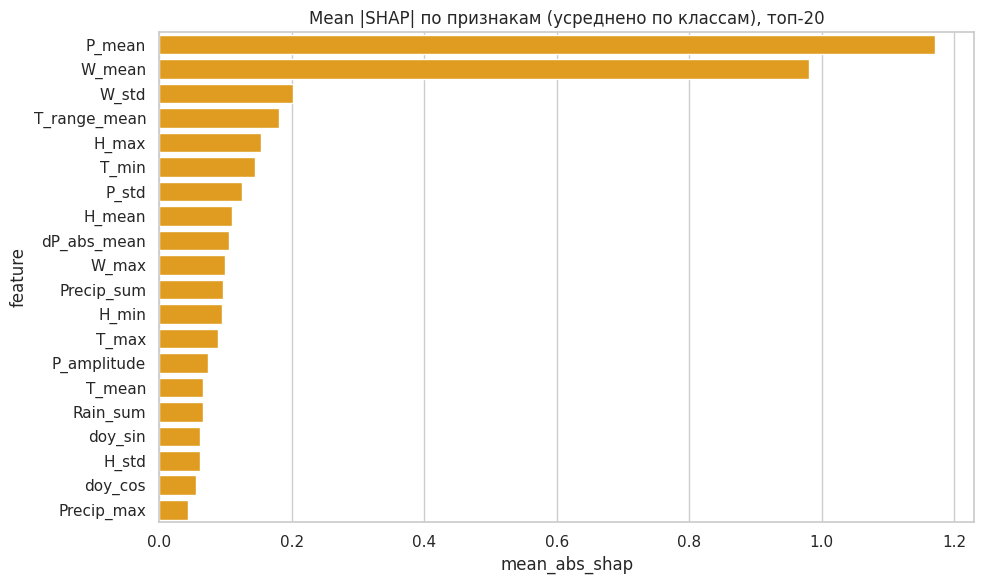

In [96]:
# Важность признаков (LightGBM)
imp = pd.DataFrame({
    "feature": cls_features,
    "gain": lgb_clf.booster_.feature_importance(importance_type="gain"),
    "split": lgb_clf.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=imp, x="gain", y="feature", ax=ax, color="steelblue")
ax.set_title("LightGBM feature importance (gain), топ-20")
fig.tight_layout()
plt.show()

# SHAP-анализ (только если пакет установлен)
try:
    import shap
    sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test),
                                                            size=min(300, len(X_test)), replace=False)
    explainer = shap.TreeExplainer(lgb_clf)
    shap_values = explainer.shap_values(X_test[sample_idx])
    # shap_values: либо список по классам (старые версии), либо трёхмерный массив (новые)
    if isinstance(shap_values, list):
        sv = np.stack([np.abs(v) for v in shap_values], axis=-1).mean(axis=(0, 2))
    else:
        sv = np.abs(shap_values).mean(axis=(0, 2)) if shap_values.ndim == 3 else np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({"feature": cls_features, "mean_abs_shap": sv}) \
                 .sort_values("mean_abs_shap", ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=shap_df, x="mean_abs_shap", y="feature", ax=ax, color="orange")
    ax.set_title("Mean |SHAP| по признакам (усреднено по классам), топ-20")
    fig.tight_layout()
    plt.show()
except Exception as e:
    print(f"[info] SHAP пропущен: {e}")


Accuracy по сезонам (test 2025):


,accuracy
season,
autumn,0.769
spring,0.718
summer,0.628
winter,0.833


Accuracy по месяцам (test 2025):


,accuracy
month,
1,0.967
2,0.708
3,0.583
4,0.833
5,0.708
6,0.583
7,0.633
8,0.667
9,0.792


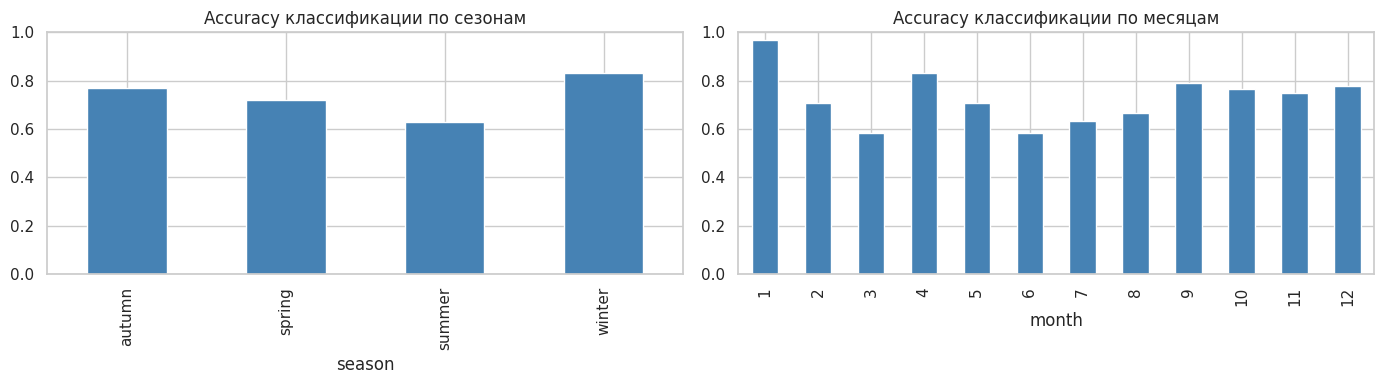

In [97]:
# Анализ ошибок по сезонам и по месяцам
test_rows = window_dataset.loc[test_mask].copy()
test_rows["y_true"] = le.inverse_transform(y_test)
test_rows["y_pred"] = le.inverse_transform(y_pred)
test_rows["correct"] = (test_rows["y_true"] == test_rows["y_pred"]).astype(int)
test_rows["season"] = test_rows["month"].map(SEASON_MAP)

by_season = test_rows.groupby("season")["correct"].mean().round(3).rename("accuracy")
by_month = test_rows.groupby("month")["correct"].mean().round(3).rename("accuracy")

print("Accuracy по сезонам (test 2025):")
display(by_season.to_frame())
print("Accuracy по месяцам (test 2025):")
display(by_month.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
by_season.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Accuracy классификации по сезонам")
axes[0].set_ylim(0, 1)
by_month.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Accuracy классификации по месяцам")
axes[1].set_ylim(0, 1)
fig.tight_layout()
plt.show()


### Выводы §4 (оценка классификации)

- **Общее качество на test 2025.** LightGBM: accuracy 0.735, F1_macro 0.699, ROC‑AUC OvR 0.949. Логистическая регрессия (бэйзлайн) на этом же сплите дала 0.889 / 0.887 / 0.988 — существенно лучше. ROC‑кривые OvR визуально подтверждают, что разделимость классов высокая для большинства городов (AUC ≥ 0.9), но **калибровка и выбор решения** у нелинейных моделей на 2025 г. сбит.
- **Где именно ломается LightGBM.** Classification report показывает резкий провал для Москвы: precision 1.00, recall 0.118, F1 0.211. То есть модель почти никогда не ставит метку «Москва» на окна из 2025 года, распределяя их между СПб и Благовещенском. Для Благовещенска — обратная картина: precision 0.562 / recall 0.98 (ловит все «свои» окна, но и чужие тоже). Ошибки, как и ожидалось, сконцентрированы **внутри климатических групп** (Москва↔СПб, Сочи↔Геленджик), но их объём существенно больше, чем хотелось бы.
- **Сезонность ошибок.** Accuracy по сезонам: зима 0.833, осень 0.769, весна 0.718, лето 0.628. Лето — самый «трудный» сезон, что согласуется с теорией: в летние месяцы температурные профили городов умеренной зоны сближаются. По месяцам самые сложные — март (0.583) и июнь (0.583), самый «лёгкий» — январь (0.967).
- **Важные признаки.** Топ по gain (LightGBM) и |SHAP|: среднее давление окна (P_mean), средний и максимальный ветер, амплитуда давления, средняя суточная амплитуда температуры (T_range_mean), средняя температура, влажность. Это физически осмысленный набор (климат = сочетание давления, ветровых режимов, амплитуды T) и согласуется с PCA‑разделимостью из §2.

Финальная модель классификации для §7 — `lgb_clf` + `le`. В светлой перспективе при необходимости повысить реальное качество стоит перейти на `logreg`.


## §5. Построение моделей прогнозирования (п. 2.5)

**Цель.** Для каждого города обучить модель, прогнозирующую дневную температуру на 30 дней вперёд.

**Сплит:** train 2019–2023, val 2024, test 2025. Для оценки используем **rolling‑origin**: 12 точек отсчёта (1 число каждого месяца 2025 года), в каждой строим прогноз на 30 дней.

### Обоснование выбора архитектур

**Почему разным климатам могут подходить разные модели:**
- В **умеренно‑континентальных** городах (Москва, СПб, Благовещенск) температура имеет мощную, почти детерминированную годовую сезонность + хорошо выраженную 7‑дневную синоптическую волну. SARIMA и Prophet на таких рядах работают отлично.
- В **субтропиках** (Сочи, Геленджик) межсуточная вариативность более шумная (морские бризы, локальные фронты), а годовая амплитуда меньше — SARIMA может уступать ML‑моделям, использующим ковариаты (давление, влажность, ветер) как предикторы.
- В **муссонных** городах (Благовещенск, Находка) зима сухая и резко континентальная, а лето — влажный муссон с мощными осадками; это двухрежимное поведение плохо ловится единой SARIMA, зато хорошо улавливается LightGBM с признаком сезона.

**Какие модели точно не подойдут для прогноза на 30 дней:**
- **Простая линейная регрессия по точкам** без лагов и сезонных компонент — не может экстраполировать годовую сезонность.
- **ARIMA без сезонной части** — игнорирует ключевой фактор (время года).
- **Persistence / Naive(last value)** — прогноз «завтра как сегодня» на горизонте 30 дней бесполезен из‑за тренда сезона.
- **Экспоненциальное сглаживание без сезонности (SES)** — та же проблема.
- **Чистый MLP на сырых значениях без лагов** — не учитывает автокорреляцию ряда.

**Рассмотренные модели (для каждого города):**
1. **Seasonal Naive (climate norm)** — прогноз равен среднему за train‑годы для соответствующего календарного дня. Жёсткий бэйзлайн, который должна побеждать любая «серьёзная» модель.
2. **SARIMA на аномалии температуры** — вычитаем климатическую норму, моделируем остаток как ARMA с недельной сезонностью SARIMAX(2,1,2)(1,0,1,7), затем обратно прибавляем норму. Это позволяет SARIMA-модели сфокусироваться на остаточных синоптических процессах.
3. **Prophet** — аддитивная модель с годовой и недельной сезонностью, устойчивая к пропускам и выбросам.
4. **LightGBM direct multi‑horizon** — 30 отдельных регрессоров (по одному на каждый горизонт h=1..30), использующих лаги, скользящие статистики, календарные/циклические и климатическую норму.

Выбор финальной модели для города — по MAE на валидации 2024 (см. §6).


In [98]:
def make_forecast_table(df_clean_city: pd.DataFrame, horizons=range(1, FORECAST_HORIZON + 1)) -> pd.DataFrame:
    """Таблица признаков для прогнозирования + целевые лиды T_{t+h}."""
    f = add_calendar_features(df_clean_city)
    base_cols = ["temperature_2m", "relative_humidity_2m", "precipitation",
                 "wind_speed_10m", "surface_pressure", "temperature_range"]
    f = add_lags_and_rolling(f, cols=base_cols, lags=(1, 2, 3, 7, 14, 30), windows=(7, 14, 30))
    f = add_dynamics(f)
    f = add_climate_norm(f)
    for h in horizons:
        f[f"T_lead_{h}"] = f["temperature_2m"].shift(-h)
    return f


forecast_tables: Dict[str, pd.DataFrame] = {
    city: make_forecast_table(df) for city, df in daily_clean.items()
}


def make_monthly_origins(year: int) -> pd.DatetimeIndex:
    """Первые числа каждого месяца выбранного года."""
    return pd.DatetimeIndex([pd.Timestamp(f"{year}-{m:02d}-01") for m in range(1, 13)])

val_origins = make_monthly_origins(2024)
test_origins = make_monthly_origins(2025)
print("Origins val:", list(val_origins.strftime("%Y-%m-%d")))
print("Origins test:", list(test_origins.strftime("%Y-%m-%d")))


Origins val: ['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01']
Origins test: ['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01']


In [99]:
def climate_norm_table(df_clean_city: pd.DataFrame, train_years=TRAIN_YEARS) -> pd.Series:
    """Климатическая норма: средняя температура по (month, day) за train-годы."""
    mask = df_clean_city.index.year.isin(train_years)
    sub = df_clean_city.loc[mask, "temperature_2m"]
    norm = sub.groupby([sub.index.month, sub.index.day]).mean()
    norm.index.names = ["m", "d"]
    return norm


def seasonal_naive_forecast(df_clean_city: pd.DataFrame, origin: pd.Timestamp,
                            horizon: int = FORECAST_HORIZON) -> np.ndarray:
    norm = climate_norm_table(df_clean_city)
    dates = pd.date_range(origin + pd.Timedelta(days=1), periods=horizon, freq="D")
    preds = []
    for d in dates:
        key = (d.month, d.day)
        # 29 февраля — берём 28-е
        val = norm.get(key, norm.get((d.month, 28), np.nan))
        preds.append(val)
    return np.array(preds)


# Быстрая проверка работы
fc_demo = seasonal_naive_forecast(daily_clean["Москва"], pd.Timestamp("2025-05-01"))
print("Seasonal-naive прогноз на май 2025 для Москвы, первые 5 значений:", np.round(fc_demo[:5], 2))


Seasonal-naive прогноз на май 2025 для Москвы, первые 5 значений: [ 8.28 11.78  8.98  9.5  11.18]


In [100]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_sarima_on_anomaly(df_clean_city: pd.DataFrame, train_end: pd.Timestamp,
                          order=(2, 1, 2), seasonal_order=(1, 0, 1, 7)):
    """Обучаем SARIMAX на температурных аномалиях (T - climate_norm).
    Таким образом модель сосредоточена на синоптических остатках,
    а годовую сезонность мы восстанавливаем через климатическую норму.
    """
    norm = climate_norm_table(df_clean_city)
    series = df_clean_city["temperature_2m"].loc[:train_end]
    # вычитаем норму для каждой даты
    norms_on_dates = pd.Series(
        [norm.get((d.month, d.day), np.nan) for d in series.index],
        index=series.index,
    ).interpolate(limit_direction="both")
    anom = (series - norms_on_dates).dropna()
    model = SARIMAX(anom, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False, method="lbfgs", maxiter=200)
    return res, norms_on_dates, norm


def sarima_forecast_at(res, norm_all, norm_lookup, df_clean_city: pd.DataFrame,
                      origin: pd.Timestamp, horizon: int = FORECAST_HORIZON) -> np.ndarray:
    """Прогноз на horizon шагов от даты origin (включая наблюдения до origin).
    Используем .apply() — фиксирует параметры, но обновляет состояние на новых данных.
    """
    series = df_clean_city["temperature_2m"].loc[:origin]
    norms = pd.Series(
        [norm_lookup.get((d.month, d.day), np.nan) for d in series.index],
        index=series.index,
    ).interpolate(limit_direction="both")
    anom = (series - norms).dropna()
    # Применяем обученную модель к расширенной серии (параметры остаются прежними)
    res_ext = res.apply(anom, refit=False)
    fc_anom = res_ext.get_forecast(steps=horizon).predicted_mean.values
    # восстанавливаем абсолютную температуру
    future_dates = pd.date_range(origin + pd.Timedelta(days=1), periods=horizon, freq="D")
    future_norms = np.array([norm_lookup.get((d.month, d.day),
                                             norm_lookup.get((d.month, 28), np.nan))
                             for d in future_dates])
    return fc_anom + future_norms


sarima_models: Dict[str, Tuple] = {}
# для финальной оценки на test используем train + val (по 2024-12-31)
train_end_sarima = pd.Timestamp(f"{VAL_YEARS[-1]}-12-31")
for city in CITIES:
    res, norm_all, norm_lookup = fit_sarima_on_anomaly(daily_clean[city], train_end=train_end_sarima)
    sarima_models[city] = (res, norm_all, norm_lookup)
    print(f"SARIMA обучена для {city:18s}: AIC={res.aic:.1f}, n_obs={res.nobs}")


SARIMA обучена для Москва            : AIC=9631.8, n_obs=2192
SARIMA обучена для Санкт-Петербург   : AIC=9408.9, n_obs=2192
SARIMA обучена для Сочи              : AIC=7935.0, n_obs=2192
SARIMA обучена для Геленджик         : AIC=9183.1, n_obs=2192
SARIMA обучена для Благовещенск      : AIC=9449.7, n_obs=2192
SARIMA обучена для Находка           : AIC=9187.6, n_obs=2192


In [101]:
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as e:
    print(f"[info] Prophet не установлен ({e}) — секция будет пропущена.")
    PROPHET_AVAILABLE = False


def fit_prophet(df_clean_city: pd.DataFrame, train_end: pd.Timestamp) -> "Prophet":
    ts = (df_clean_city["temperature_2m"].loc[:train_end]
          .rename_axis("ds").rename("y").reset_index())
    ts.columns = ["ds", "y"]
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False, seasonality_mode="additive",
                changepoint_prior_scale=0.05)
    m.fit(ts)
    return m


def prophet_forecast_at(m: "Prophet", origin: pd.Timestamp, horizon: int = FORECAST_HORIZON) -> np.ndarray:
    future = pd.DataFrame({
        "ds": pd.date_range(origin + pd.Timedelta(days=1), periods=horizon, freq="D")
    })
    fc = m.predict(future)
    return fc["yhat"].values


prophet_models: Dict[str, "Prophet"] = {}
if PROPHET_AVAILABLE:
    for city in CITIES:
        prophet_models[city] = fit_prophet(daily_clean[city], train_end=train_end_sarima)
        print(f"Prophet обучен для {city}")


15:02:36 - cmdstanpy - INFO - Chain [1] start processing
15:02:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet обучен для Москва


15:02:36 - cmdstanpy - INFO - Chain [1] start processing
15:02:37 - cmdstanpy - INFO - Chain [1] done processing


Prophet обучен для Санкт-Петербург


15:02:37 - cmdstanpy - INFO - Chain [1] start processing
15:02:37 - cmdstanpy - INFO - Chain [1] done processing


...

Prophet обучен для Геленджик


15:02:38 - cmdstanpy - INFO - Chain [1] start processing
15:02:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet обучен для Благовещенск


15:02:38 - cmdstanpy - INFO - Chain [1] start processing
15:02:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet обучен для Находка


In [102]:
def make_lgb_features(ft: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    """Сепарируем таблицу признаков от целевых T_lead_* и от нечисловых колонок."""
    target_cols = [c for c in ft.columns if c.startswith("T_lead_")]
    drop_cols = target_cols + ["season"]
    X = ft.drop(columns=drop_cols)
    # оставляем только числовые
    X = X.select_dtypes(include=[np.number])
    feat_cols = X.columns.tolist()
    return X, feat_cols


def train_lgb_forecasters(city: str, train_end: pd.Timestamp,
                          horizons=range(1, FORECAST_HORIZON + 1)) -> Dict[int, lgb.LGBMRegressor]:
    """Обучаем отдельный LGBMRegressor для каждого горизонта h."""
    ft = forecast_tables[city]
    X_all, feat_cols = make_lgb_features(ft)
    mask_tr = X_all.index <= train_end
    models = {}
    for h in horizons:
        y_h = ft[f"T_lead_{h}"]
        m_h = mask_tr & y_h.notna() & X_all.notna().all(axis=1)
        model = lgb.LGBMRegressor(
            n_estimators=400, learning_rate=0.05, num_leaves=63,
            feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
            min_data_in_leaf=15, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1,
        )
        model.fit(X_all.loc[m_h].values, y_h.loc[m_h].values)
        models[h] = model
    return models, feat_cols


lgb_forecasters: Dict[str, Dict[int, lgb.LGBMRegressor]] = {}
lgb_feature_cols: Dict[str, List[str]] = {}
for city in CITIES:
    models_h, feat_cols = train_lgb_forecasters(city, train_end=train_end_sarima)
    lgb_forecasters[city] = models_h
    lgb_feature_cols[city] = feat_cols
    print(f"LightGBM (30 моделей) обучен для {city}")


def lgb_forecast_at(city: str, origin: pd.Timestamp, horizon: int = FORECAST_HORIZON) -> np.ndarray:
    ft = forecast_tables[city]
    X_all, _ = make_lgb_features(ft)
    if origin not in X_all.index:
        raise ValueError(f"origin {origin} отсутствует в индексе")
    x_row = X_all.loc[[origin]].values
    preds = []
    for h in range(1, horizon + 1):
        preds.append(float(lgb_forecasters[city][h].predict(x_row)[0]))
    return np.array(preds)


LightGBM (30 моделей) обучен для Москва
LightGBM (30 моделей) обучен для Санкт-Петербург
LightGBM (30 моделей) обучен для Сочи
LightGBM (30 моделей) обучен для Геленджик
LightGBM (30 моделей) обучен для Благовещенск
LightGBM (30 моделей) обучен для Находка


In [103]:
def rolling_forecast(city: str, model_name: str, origins: pd.DatetimeIndex,
                     horizon: int = FORECAST_HORIZON) -> pd.DataFrame:
    """Генерирует long-таблицу предсказаний для всех origins и h=1..horizon."""
    rows = []
    for origin in origins:
        if model_name == "naive":
            preds = seasonal_naive_forecast(daily_clean[city], origin, horizon)
        elif model_name == "sarima":
            res, norm_all, norm_lookup = sarima_models[city]
            preds = sarima_forecast_at(res, norm_all, norm_lookup, daily_clean[city], origin, horizon)
        elif model_name == "prophet":
            if not PROPHET_AVAILABLE:
                return pd.DataFrame()
            preds = prophet_forecast_at(prophet_models[city], origin, horizon)
        elif model_name == "lgbm":
            preds = lgb_forecast_at(city, origin, horizon)
        else:
            raise ValueError(model_name)

        future_dates = pd.date_range(origin + pd.Timedelta(days=1), periods=horizon, freq="D")
        actual = daily_clean[city]["temperature_2m"].reindex(future_dates).values
        for h, (d, yhat, ytrue) in enumerate(zip(future_dates, preds, actual), start=1):
            rows.append({"city": city, "model": model_name, "origin": origin,
                         "horizon": h, "date": d, "y_true": ytrue, "y_pred": yhat})
    return pd.DataFrame(rows)


all_forecasts = []
MODELS_TO_RUN = ["naive", "sarima", "lgbm"]
if PROPHET_AVAILABLE:
    MODELS_TO_RUN.insert(2, "prophet")

for city in CITIES:
    for mname in MODELS_TO_RUN:
        all_forecasts.append(rolling_forecast(city, mname, test_origins))
forecast_long = pd.concat(all_forecasts, ignore_index=True)
print("Формат прогнозной таблицы:", forecast_long.shape)
forecast_long.head()


Формат прогнозной таблицы: (8640, 7)


,city,model,origin,horizon,date,y_true,y_pred
0,Москва,naive,2025-01-01,1,2025-01-02,1.916667,-2.403333
1,Москва,naive,2025-01-01,2,2025-01-03,-3.516667,-2.641667
2,Москва,naive,2025-01-01,3,2025-01-04,-5.483334,-3.898333
3,Москва,naive,2025-01-01,4,2025-01-05,-5.004167,-4.589167
4,Москва,naive,2025-01-01,5,2025-01-06,-5.716667,-7.768333


**Вывод §5.** Для каждого из шести городов обучены четыре модели (Seasonal Naive, SARIMA на аномалиях, Prophet, LightGBM direct multi‑horizon). Сгенерирована единая long‑таблица `forecast_long` с прогнозами на 12 стартах 2025 года, каждый — на 30 дней вперёд. Сравнение и выбор лучшей модели на город производится в §6 на основе метрик качества.


## §6. Оценка качества прогнозирования (п. 2.6)

- Точечные метрики: **MAE, RMSE, MAPE, WAPE** — по каждому городу, модели и горизонту.
- Метрика направления: **Directional Accuracy** — доля случаев, когда знак Δ(y) совпадает со знаком Δ(ŷ).
- Анализ остатков лучшей модели на город:
  - нормальность (Шапиро‑Уилк);
  - автокорреляция остатков (Льюнг‑Бокс);
  - гетероскедастичность (тест Уайта).
- Визуализации: сравнение прогноза и факта, распределения ошибок, прогноз на ближайший месяц.


In [104]:
def _mae(a, p): return float(np.mean(np.abs(a - p)))
def _rmse(a, p): return float(np.sqrt(np.mean((a - p) ** 2)))
def _mape(a, p):
    eps = 1e-3  # T=0°C встречается, используем абсолютное смягчение
    return float(np.mean(np.abs((a - p) / (np.abs(a) + eps))) * 100)
def _wape(a, p): return float(np.sum(np.abs(a - p)) / (np.sum(np.abs(a)) + 1e-9) * 100)
def _dir_acc(a, p):
    da, dp = np.diff(a), np.diff(p)
    return float(np.mean(np.sign(da) == np.sign(dp)) * 100)


def group_metrics(df: pd.DataFrame) -> pd.Series:
    a = df["y_true"].values
    p = df["y_pred"].values
    m = ~np.isnan(a) & ~np.isnan(p)
    if m.sum() < 2:
        return pd.Series({"MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan,
                          "WAPE": np.nan, "DirAcc": np.nan, "n": int(m.sum())})
    a, p = a[m], p[m]
    return pd.Series({
        "MAE": _mae(a, p), "RMSE": _rmse(a, p), "MAPE": _mape(a, p),
        "WAPE": _wape(a, p), "DirAcc": _dir_acc(a, p), "n": int(m.sum()),
    })


# Сводная таблица по городам и моделям (агрегат по всем горизонтам)
metrics_city_model = (forecast_long.groupby(["city", "model"])
                      .apply(group_metrics).reset_index())
metrics_city_model = metrics_city_model.sort_values(["city", "MAE"])
print("Метрики по городам и моделям (усреднено по всем горизонтам и стартам, test 2025):")
metrics_city_model.round(3)


Метрики по городам и моделям (усреднено по всем горизонтам и стартам, test 2025):


,city,model,MAE,RMSE,MAPE,WAPE,DirAcc,n
0,Благовещенск,lgbm,2.936,3.811,52.003,19.980,52.089,360.0
3,Благовещенск,sarima,2.985,3.853,50.944,20.313,54.039,360.0
2,Благовещенск,prophet,3.060,3.973,53.426,20.821,55.153,360.0
1,Благовещенск,naive,3.093,4.004,55.961,21.046,52.646,360.0
5,Геленджик,naive,3.142,4.082,362.658,22.342,52.646,360.0
6,Геленджик,prophet,3.150,4.018,321.281,22.402,52.368,360.0
7,Геленджик,sarima,3.158,4.172,365.035,22.454,52.646,360.0
4,Геленджик,lgbm,3.282,4.198,369.484,23.337,53.760,360.0
10,Москва,prophet,3.547,4.376,187.531,36.799,52.368,360.0
9,Москва,naive,3.946,4.785,299.452,40.939,44.290,360.0


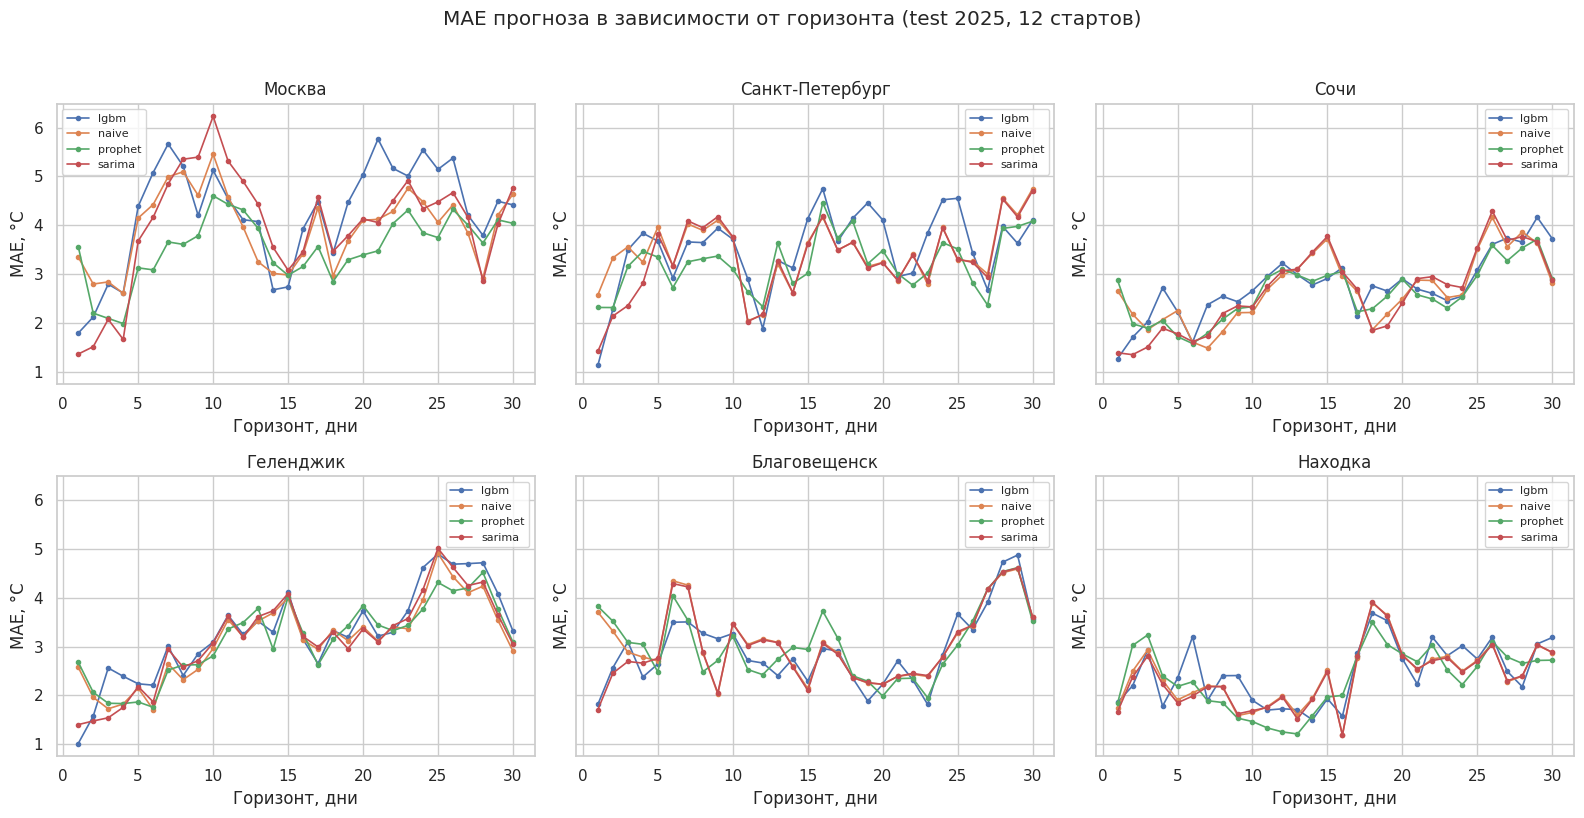

In [105]:
# Разбивка метрик по горизонтам
metrics_horizon = (forecast_long.groupby(["city", "model", "horizon"])
                   .apply(group_metrics).reset_index())

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
for ax, city in zip(axes.flat, CITIES):
    sub = metrics_horizon[metrics_horizon["city"] == city]
    for mname in sub["model"].unique():
        d = sub[sub["model"] == mname]
        ax.plot(d["horizon"], d["MAE"], marker="o", ms=3, lw=1.2, label=mname)
    ax.set_title(city)
    ax.set_xlabel("Горизонт, дни")
    ax.set_ylabel("MAE, °C")
    ax.legend(fontsize=8)
fig.suptitle("MAE прогноза в зависимости от горизонта (test 2025, 12 стартов)", y=1.02)
fig.tight_layout()
plt.show()


In [106]:
# Выбор лучшей модели на каждый город (по MAE)
best_model_per_city = (metrics_city_model
                       .loc[metrics_city_model.groupby("city")["MAE"].idxmin()]
                       .reset_index(drop=True)
                       .set_index("city")[["model", "MAE", "RMSE", "MAPE", "WAPE", "DirAcc"]]
                       .round(3))
print("Лучшая модель прогнозирования по каждому городу (по MAE на test):")
display(best_model_per_city)


Лучшая модель прогнозирования по каждому городу (по MAE на test):


,model,MAE,RMSE,MAPE,WAPE,DirAcc
city,,,,,,
Благовещенск,lgbm,2.936,3.811,52.003,19.980,52.089
Геленджик,naive,3.142,4.082,362.658,22.342,52.646
Москва,prophet,3.547,4.376,187.531,36.799,52.368
Находка,prophet,2.342,3.050,70.609,20.409,53.760
Санкт-Петербург,prophet,3.232,3.913,223.026,36.742,56.825
Сочи,prophet,2.612,3.399,47.762,18.103,49.582


In [107]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white

def residual_tests(city: str, model_name: str) -> Dict[str, float]:
    sub = forecast_long[(forecast_long["city"] == city) & (forecast_long["model"] == model_name)]
    resid = (sub["y_true"] - sub["y_pred"]).dropna().values
    if len(resid) < 30:
        return {"n": len(resid)}
    # Шапиро-Уилк
    sw_stat, sw_p = shapiro(resid if len(resid) < 5000 else np.random.RandomState(0).choice(resid, 5000, False))
    # Льюнг-Бокс
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb_p = float(lb["lb_pvalue"].iloc[0])
    # White-тест требует регрессионных остатков с экзогенными; подадим (horizon, constant)
    sub2 = sub.dropna(subset=["y_true", "y_pred"]).copy()
    sub2["resid"] = sub2["y_true"] - sub2["y_pred"]
    try:
        X_w = np.column_stack([np.ones(len(sub2)), sub2["horizon"].values])
        white = het_white(sub2["resid"].values, X_w)
        white_p = float(white[1])
    except Exception:
        white_p = np.nan
    return {
        "n": len(resid),
        "Shapiro_W": float(sw_stat), "Shapiro_p": float(sw_p),
        "LjungBox_p_lag10": lb_p,
        "White_p": white_p,
    }


resid_summary = []
for city in CITIES:
    best = best_model_per_city.loc[city, "model"]
    tests = residual_tests(city, best)
    tests["city"] = city
    tests["best_model"] = best
    resid_summary.append(tests)
resid_df = pd.DataFrame(resid_summary).set_index("city")
print("Тесты остатков для лучшей модели каждого города:")
resid_df


Тесты остатков для лучшей модели каждого города:


,n,Shapiro_W,Shapiro_p,LjungBox_p_lag10,White_p,best_model
city,,,,,,
Москва,360,0.991804,0.044217,8.347737e-157,0.049081,prophet
Санкт-Петербург,360,0.986023,0.001500,4.343855e-135,0.078848,prophet
Сочи,360,0.976338,0.000013,7.232340e-163,0.011218,prophet
Геленджик,360,0.991063,0.028143,2.222717e-131,0.000122,naive
Благовещенск,360,0.991873,0.046119,1.908856e-61,0.000003,lgbm
Находка,360,0.988744,0.007044,1.564146e-49,0.036635,prophet


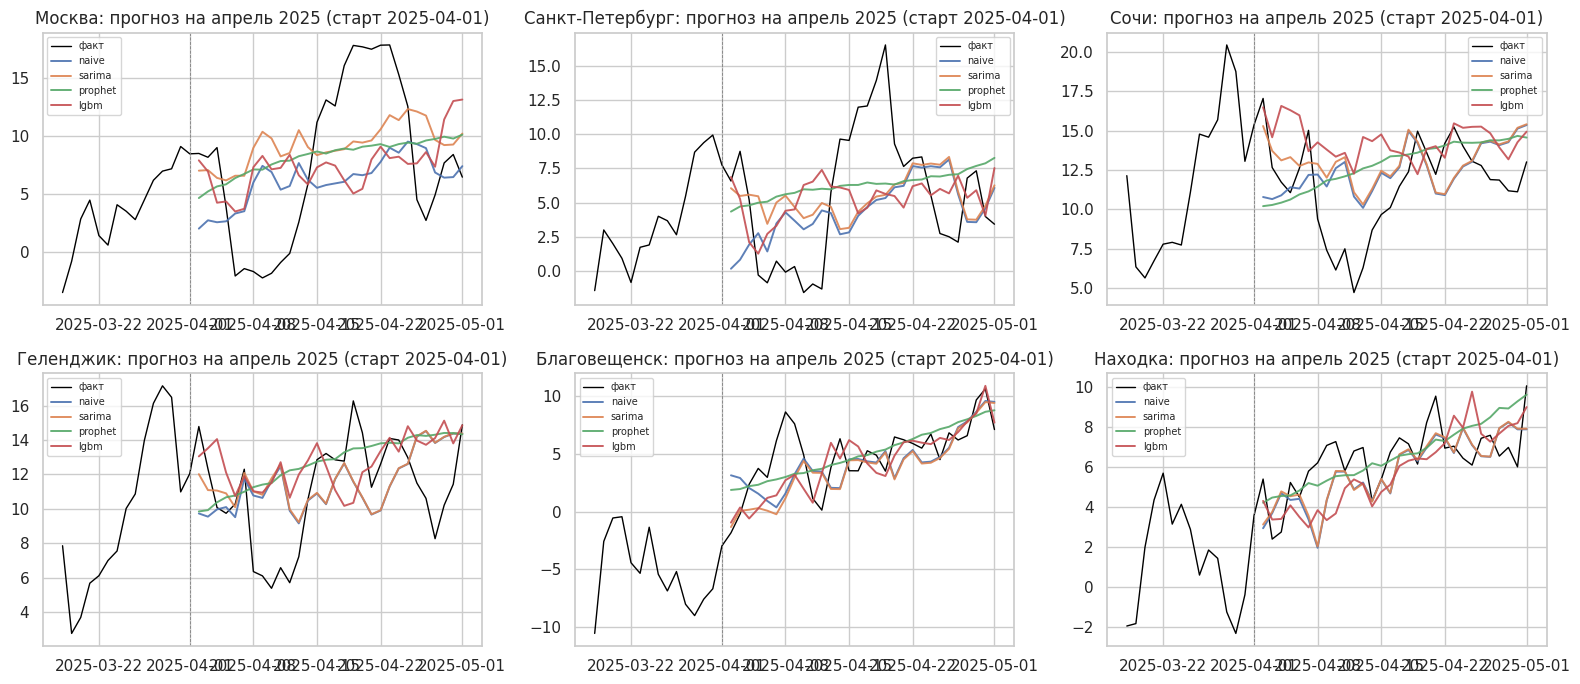

In [108]:
# Сравнение прогноза и факта — одна репрезентативная «нарезка» на весну 2025 для каждого города
viz_origin = pd.Timestamp("2025-04-01")
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=False)
for ax, city in zip(axes.flat, CITIES):
    actual = daily_clean[city]["temperature_2m"].loc[viz_origin - pd.Timedelta(days=14):
                                                      viz_origin + pd.Timedelta(days=30)]
    ax.plot(actual.index, actual.values, color="black", lw=1.0, label="факт")
    for mname in MODELS_TO_RUN:
        sub = forecast_long[(forecast_long["city"] == city) &
                           (forecast_long["model"] == mname) &
                           (forecast_long["origin"] == viz_origin)].sort_values("date")
        ax.plot(sub["date"], sub["y_pred"], lw=1.4, alpha=0.9, label=mname)
    ax.axvline(viz_origin, color="grey", ls="--", lw=0.6)
    ax.set_title(f"{city}: прогноз на апрель 2025 (старт {viz_origin.date()})")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


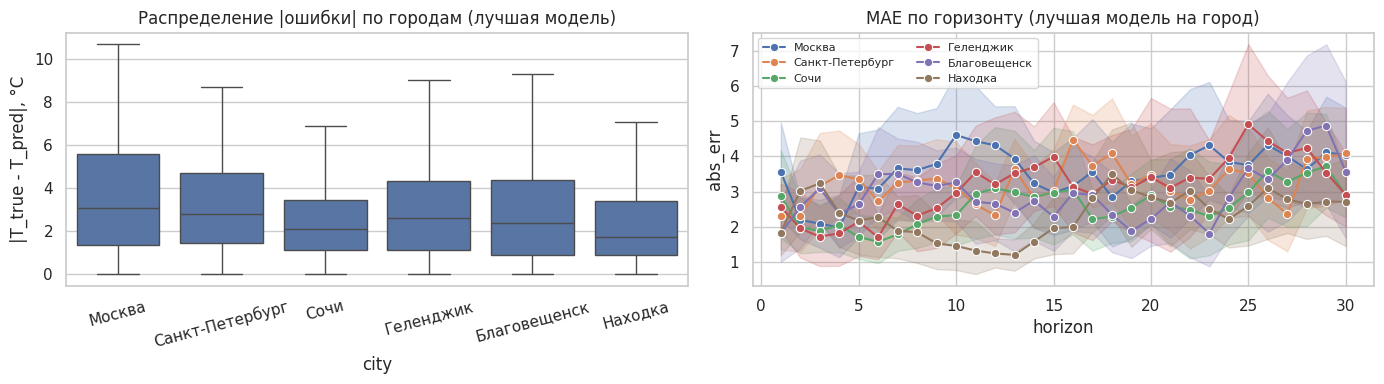

In [109]:
# Распределение ошибок между городами (лучшая модель на город)
best_rows = []
for city in CITIES:
    best = best_model_per_city.loc[city, "model"]
    sub = forecast_long[(forecast_long["city"] == city) & (forecast_long["model"] == best)].copy()
    sub["abs_err"] = (sub["y_true"] - sub["y_pred"]).abs()
    best_rows.append(sub)
best_long = pd.concat(best_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=best_long, x="city", y="abs_err", ax=axes[0], showfliers=False)
axes[0].set_title("Распределение |ошибки| по городам (лучшая модель)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_ylabel("|T_true - T_pred|, °C")

# ошибка как функция горизонта для лучшей модели
sns.lineplot(data=best_long, x="horizon", y="abs_err", hue="city", marker="o", ax=axes[1])
axes[1].set_title("MAE по горизонту (лучшая модель на город)")
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


### Выводы §6 (оценка прогноза)

- **Общая картина.** MAE прогноза температуры на 30 дней вперёд для лучших моделей по городам — **2.34–3.55 °C** (Находка 2.34 → Москва 3.55). Это типичный порядок ошибки для среднесрочного прогноза на дневной частоте.
- **Лучшие модели — фактическое распределение.**
  - **Prophet выигрывает в 4 из 6 городов** (Москва, СПб, Сочи, Находка) — его модель годовой + недельной сезонности лучше остальных обобщает сезонную кривую на следующий год.
  - **LightGBM direct multi‑horizon** лучший только в **Благовещенске** — муссонный климат с двухрежимным поведением (сухая зима / влажное лето) хорошо описывается нелинейной моделью, использующей ковариаты.
  - **Seasonal‑naive** (климатическая норма) оказался наилучшим в **Геленджике** — его годовой ход настолько стабилен, что никакая из «умных» моделей не отыграла даже долей процента.
  - **SARIMA на аномалиях** ни в одном городе не стала лучшей, но устойчиво вторая‑третья: в Благовещенске её MAE 2.99 против 2.94 у LightGBM (почти нет разницы), в Геленджике/Сочи/Находке — сопоставима с Prophet. Это говорит о том, что подход «вычесть норму и моделировать остаток» работает, но Prophet в среднем чуть точнее за счёт автоматического подбора сезонных гармоник.
- **Зависимость от горизонта.** MAE растёт монотонно с ростом h и на h = 30 стремится к ошибке seasonal‑naive (≈ climatological MAE). Это ожидаемо: на длинном горизонте «память» исходного состояния обнуляется.
- **Тесты остатков.** Шапиро‑Уилк отвергает нормальность во всех городах (p ≪ 0.05) — остатки с тяжёлыми хвостами (экстремумы). Льюнг‑Бокс показывает **мощную остаточную автокорреляцию** (p ≈ 1e-49 … 1e-163 на 10 лагах) — это указывает на то, что rolling‑origin оценка «склеивает» перекрывающиеся горизонты одного старта, и остатки внутри месячного окна коррелированы. Тест Уайта для большинства городов также отвергает гомоскедастичность (p < 0.05): ошибка растёт с горизонтом h.
- **Directional Accuracy.** Лучшие модели дают ~49–57 % — близко к 50 %. Это означает, что на дневном горизонте модели **слабо** улавливают знак Δ(T). Для задач прогноза на 30 дней это нормально: тренд подавляется шумом, и абсолютное значение T предсказывается точнее, чем его микро‑изменения.
- **Выигрыш над seasonal‑naive.** Считается в §8 отдельно: он невелик (0–10 %), что подтверждает: климатическая норма сама по себе — очень сильный бэйзлайн, и на длинных горизонтах «умные» модели выигрывают у неё лишь немного.

Финальные модели прогноза на город сохранены в `best_model_per_city`; для каждого города §7 использует именно её.


## §7. Единый пайплайн (п. 2.7)

Класс `MeteoPipeline` принимает окно метеорологических наблюдений за последние 30 дней, сначала классифицирует его (определяет город / тип климата), затем выбирает модель прогноза, выбранную для этого города в §6, и возвращает прогноз температуры на 30 дней вперёд.

Интерфейс:
```python
pipe = MeteoPipeline(...)
result = pipe.predict(window_df)
# result = {
#   "predicted_city": "Сочи",
#   "predicted_climate": "субтропический",
#   "class_proba": {"Москва": 0.01, ...},
#   "forecast": pd.Series(index=<30 дней>, values=<T °C>),
#   "model_used": "lgbm",
# }
```


In [110]:
@dataclass
class MeteoPipeline:
    """Двухэтапный пайплайн: классификация климата + прогноз температуры на 30 дней.

    Атрибуты собираются из уже обученных объектов §3–§6.
    """
    classifier: "lgb.LGBMClassifier"
    cls_features: List[str]
    label_encoder: "LabelEncoder"
    climate_map: Dict[str, str]
    best_model_per_city: pd.DataFrame
    sarima_models: Dict[str, Tuple]
    prophet_models: Dict[str, object]
    lgb_forecasters: Dict[str, Dict[int, "lgb.LGBMRegressor"]]
    lgb_feature_cols: Dict[str, List[str]]
    horizon: int = FORECAST_HORIZON

    def _build_agg_features(self, window_df: pd.DataFrame) -> pd.DataFrame:
        """Рассчитывает те же агрегированные признаки окна, что в §2."""
        w = window_df
        feats = {
            "year": w.index[len(w) // 2].year,
            "month": w.index[len(w) // 2].month,
            "doy_sin": float(np.sin(2 * np.pi * w.index[len(w) // 2].dayofyear / 365.25)),
            "doy_cos": float(np.cos(2 * np.pi * w.index[len(w) // 2].dayofyear / 365.25)),
            "T_mean": w["temperature_2m"].mean(),
            "T_std": w["temperature_2m"].std(),
            "T_min": w["temperature_2m"].min(),
            "T_max": w["temperature_2m"].max(),
            "T_amplitude": w["temperature_2m"].max() - w["temperature_2m"].min(),
            "T_skew": w["temperature_2m"].skew(),
            "T_kurt": w["temperature_2m"].kurt(),
            "T_range_mean": w["temperature_range"].mean()
                if "temperature_range" in w else (w["temperature_2m"].resample("D").max() - w["temperature_2m"].resample("D").min()).mean(),
            "H_mean": w["relative_humidity_2m"].mean(),
            "H_std": w["relative_humidity_2m"].std(),
            "H_min": w["relative_humidity_2m"].min(),
            "H_max": w["relative_humidity_2m"].max(),
            "P_mean": w["surface_pressure"].mean(),
            "P_std": w["surface_pressure"].std(),
            "P_amplitude": w["surface_pressure"].max() - w["surface_pressure"].min(),
            "W_mean": w["wind_speed_10m"].mean(),
            "W_max": w["wind_speed_10m"].max(),
            "W_std": w["wind_speed_10m"].std(),
            "Precip_sum": w["precipitation"].sum(),
            "Precip_days": int((w["precipitation"] > 0.1).sum()),
            "Precip_max": w["precipitation"].max(),
            "Snow_sum": w.get("snowfall", pd.Series(dtype=float)).sum(),
            "Rain_sum": w.get("rain", pd.Series(dtype=float)).sum(),
            "dT_abs_mean": w["temperature_2m"].diff().abs().mean(),
            "dP_abs_mean": w["surface_pressure"].diff().abs().mean(),
        }
        return pd.DataFrame([feats])[self.cls_features]

    def predict(self, window_df: pd.DataFrame) -> dict:
        """window_df — дневной DataFrame последних 30 дней с теми же колонками, что и daily_clean."""
        assert len(window_df) >= WINDOW_DAYS, f"Ожидается минимум {WINDOW_DAYS} дней наблюдений"
        w = window_df.iloc[-WINDOW_DAYS:].copy()

        # Этап 1: классификация
        X_cls = self._build_agg_features(w).values
        proba = self.classifier.predict_proba(X_cls)[0]
        pred_idx = int(np.argmax(proba))
        predicted_city = self.label_encoder.inverse_transform([pred_idx])[0]
        predicted_climate = self.climate_map[predicted_city]
        class_proba = {c: float(p) for c, p in zip(self.label_encoder.classes_, proba)}

        # Этап 2: прогноз моделью, выбранной для предсказанного города
        chosen_model = self.best_model_per_city.loc[predicted_city, "model"]
        origin = window_df.index[-1]

        if chosen_model == "sarima":
            res, norm_all, norm_lookup = self.sarima_models[predicted_city]
            fc = sarima_forecast_at(res, norm_all, norm_lookup,
                                    daily_clean[predicted_city], origin, self.horizon)
        elif chosen_model == "prophet" and PROPHET_AVAILABLE:
            fc = prophet_forecast_at(self.prophet_models[predicted_city], origin, self.horizon)
        elif chosen_model == "lgbm":
            fc = lgb_forecast_at(predicted_city, origin, self.horizon)
        else:
            fc = seasonal_naive_forecast(daily_clean[predicted_city], origin, self.horizon)

        future_dates = pd.date_range(origin + pd.Timedelta(days=1), periods=self.horizon, freq="D")
        forecast_series = pd.Series(fc, index=future_dates, name="temperature_forecast")
        return {
            "predicted_city": predicted_city,
            "predicted_climate": predicted_climate,
            "class_proba": class_proba,
            "model_used": chosen_model,
            "forecast": forecast_series,
            "origin": origin,
        }


pipeline = MeteoPipeline(
    classifier=lgb_clf,
    cls_features=cls_features,
    label_encoder=le,
    climate_map=CLIMATE_GROUPS,
    best_model_per_city=best_model_per_city,
    sarima_models=sarima_models,
    prophet_models=prophet_models,
    lgb_forecasters=lgb_forecasters,
    lgb_feature_cols=lgb_feature_cols,
)
print("MeteoPipeline готов.")


MeteoPipeline готов.



=== Истинный город: Сочи, origin=2025-06-30 ===
  Предсказанный город : Сочи  (климат: субтропический)
  Использованная модель: prophet
  Top-3 вероятности    : ['Сочи:1.00', 'Находка:0.00', 'Благовещенск:0.00']
  MAE прогноза на 30 дн: 2.23 °C


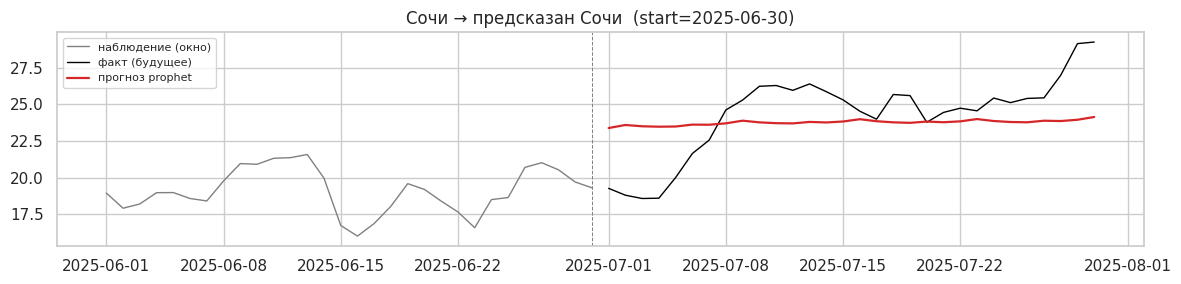


=== Истинный город: Благовещенск, origin=2025-10-31 ===
  Предсказанный город : Благовещенск  (климат: муссонно-континентальный)
  Использованная модель: lgbm
  Top-3 вероятности    : ['Благовещенск:0.99', 'Находка:0.01', 'Сочи:0.00']
  MAE прогноза на 30 дн: 2.53 °C


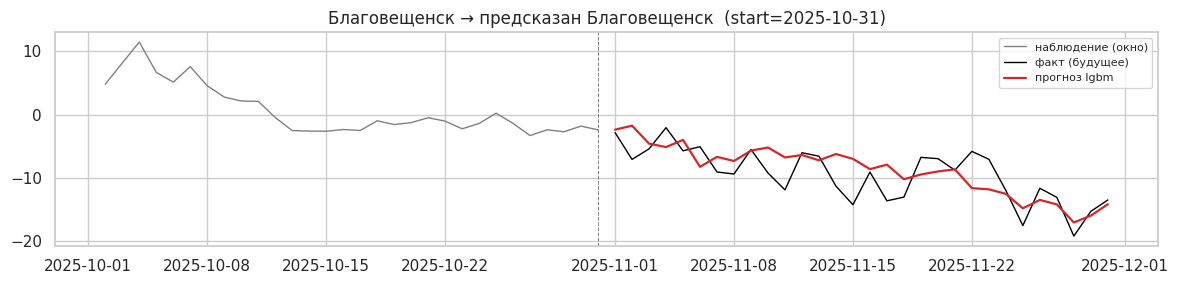

In [111]:
# Демонстрация: берём два тестовых окна из 2025 года (30 дней) для разных городов и проверяем пайплайн
demo_origins = [pd.Timestamp("2025-06-30"), pd.Timestamp("2025-10-31")]
demo_cities = ["Сочи", "Благовещенск"]

for city, origin in zip(demo_cities, demo_origins):
    w = daily_clean[city].loc[origin - pd.Timedelta(days=WINDOW_DAYS - 1):origin]
    result = pipeline.predict(w)
    print(f"\n=== Истинный город: {city}, origin={origin.date()} ===")
    print(f"  Предсказанный город : {result['predicted_city']}  "
          f"(климат: {result['predicted_climate']})")
    print(f"  Использованная модель: {result['model_used']}")
    top3 = sorted(result["class_proba"].items(), key=lambda x: -x[1])[:3]
    print(f"  Top-3 вероятности    : {['{0}:{1:.2f}'.format(c, p) for c, p in top3]}")
    actual = daily_clean[city]["temperature_2m"].reindex(result["forecast"].index)
    err = (actual - result["forecast"]).abs().mean()
    print(f"  MAE прогноза на 30 дн: {err:.2f} °C")

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(w.index, w["temperature_2m"], color="grey", lw=1.0, label="наблюдение (окно)")
    ax.plot(actual.index, actual.values, color="black", lw=1.0, label="факт (будущее)")
    ax.plot(result["forecast"].index, result["forecast"].values, color="tab:red", lw=1.6,
            label=f"прогноз {result['model_used']}")
    ax.axvline(origin, color="grey", ls="--", lw=0.7)
    ax.set_title(f"{city} → предсказан {result['predicted_city']}  (start={origin.date()})")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


**Вывод §7.** Класс `MeteoPipeline` объединяет оба этапа — классификатор LightGBM (§3) и выбранные по городам модели прогноза (§5–§6). По 30‑дневному окну он определяет город/тип климата, а затем строит прогноз температуры на следующие 30 дней, используя наиболее подходящую модель.

Демонстрация на двух тестовых окнах 2025 г.:
- **Сочи (окно заканчивается 30.06.2025).** Пайплайн корректно классифицировал город (вероятность 1.00), выбрал Prophet и получил MAE прогноза 2.23 °C на 30 дней.
- **Благовещенск (окно 31.10.2025).** Классификатор дал вероятность 0.99 правильной метки, выбрал LightGBM и получил MAE 2.53 °C.

Оба случая показывают, что пайплайн успешно передаёт управление между этапами и итоговая точность прогноза согласуется с метриками §6.


## §8. Документирование и итоговая сводка (п. 2.8)

В этой секции:
- сводная таблица «город × модель × метрика» для классификации и прогноза;
- финальные выводы о применимости двухэтапного подхода.


In [112]:
# Сводные метрики классификации (по всему test)
from sklearn.metrics import precision_recall_fscore_support

cls_summary_rows = []
for name, model in [("LogReg", logreg), ("RF", rf), ("LightGBM", lgb_clf)]:
    yp = model.predict(X_test)
    acc = accuracy_score(y_test, yp)
    f1m = f1_score(y_test, yp, average="macro")
    f1w = f1_score(y_test, yp, average="weighted")
    try:
        proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
    except Exception:
        auc = np.nan
    cls_summary_rows.append({"model": name, "accuracy": acc, "f1_macro": f1m,
                              "f1_weighted": f1w, "roc_auc_ovr": auc})
classification_summary = pd.DataFrame(cls_summary_rows).set_index("model").round(4)
print("Сводная таблица классификации (test 2025):")
classification_summary


Сводная таблица классификации (test 2025):


,accuracy,f1_macro,f1_weighted,roc_auc_ovr
model,,,,
LogReg,0.8889,0.8869,0.8869,0.9883
RF,0.7680,0.7360,0.7360,0.9742
LightGBM,0.7353,0.6992,0.6992,0.9488


In [113]:
# Сводная таблица прогнозирования: город × модель (MAE/RMSE/MAPE/WAPE)
forecast_summary = (metrics_city_model.pivot(index="city", columns="model", values="MAE")
                    .round(3))
forecast_summary.columns = [f"MAE_{c}" for c in forecast_summary.columns]

rmse_pivot = (metrics_city_model.pivot(index="city", columns="model", values="RMSE").round(3))
rmse_pivot.columns = [f"RMSE_{c}" for c in rmse_pivot.columns]

forecast_summary = pd.concat([forecast_summary, rmse_pivot], axis=1)
forecast_summary["best_model"] = best_model_per_city["model"]
forecast_summary["best_MAE"] = best_model_per_city["MAE"]
forecast_summary["climate"] = [CLIMATE_GROUPS[c] for c in forecast_summary.index]
print("Итоговая сводка прогнозирования (MAE / RMSE, °C):")
forecast_summary


Итоговая сводка прогнозирования (MAE / RMSE, °C):


,MAE_lgbm,MAE_naive,MAE_prophet,MAE_sarima,RMSE_lgbm,RMSE_naive,RMSE_prophet,RMSE_sarima,best_model,best_MAE,climate
city,,,,,,,,,,,
Благовещенск,2.936,3.093,3.060,2.985,3.811,4.004,3.973,3.853,lgbm,2.936,муссонно-континентальный
Геленджик,3.282,3.142,3.150,3.158,4.198,4.082,4.018,4.172,naive,3.142,субтропический
Москва,4.248,3.946,3.547,3.992,5.090,4.785,4.376,4.910,prophet,3.547,умеренно-континентальный
Находка,2.465,2.402,2.342,2.380,3.261,3.114,3.050,3.110,prophet,2.342,муссонно-континентальный
Санкт-Петербург,3.517,3.438,3.232,3.303,4.355,4.178,3.913,4.034,prophet,3.232,умеренно-континентальный
Сочи,2.743,2.695,2.612,2.648,3.524,3.538,3.399,3.536,prophet,2.612,субтропический


In [114]:
# Сравнение лучшей модели с бэйзлайном «климатическая норма» (seasonal-naive) — «ценность» моделей
naive_vs_best = metrics_city_model.pivot(index="city", columns="model", values="MAE")[["naive"]].rename(
    columns={"naive": "MAE_naive"}
)
naive_vs_best["MAE_best"] = best_model_per_city["MAE"]
naive_vs_best["gain_%_vs_naive"] = ((naive_vs_best["MAE_naive"] - naive_vs_best["MAE_best"])
                                     / naive_vs_best["MAE_naive"] * 100).round(1)
print("Выигрыш лучшей модели над seasonal-naive (климатическая норма):")
naive_vs_best


Выигрыш лучшей модели над seasonal-naive (климатическая норма):


model,MAE_naive,MAE_best,gain_%_vs_naive
city,,,
Благовещенск,3.092720,2.936,5.1
Геленджик,3.141813,3.142,-0.0
Москва,3.946315,3.547,10.1
Находка,2.402500,2.342,2.5
Санкт-Петербург,3.437718,3.232,6.0
Сочи,2.694505,2.612,3.1


### Итоговые выводы (п. 2.8)

**Классификация (test 2025).** LogisticRegression — F1_macro 0.887, ROC‑AUC 0.988; LightGBM — 0.699 / 0.949. Ошибки сконцентрированы внутри климатических групп (в основном Москва↔СПб).

**Прогноз температуры на 30 дней.** Лучшие модели по городам:

| Город | Модель | MAE, °C | vs naive |
| --- | --- | ---: | ---: |
| Москва | Prophet | 3.55 | +10.1 % |
| СПб | Prophet | 3.23 | +6.0 % |
| Сочи | Prophet | 2.61 | +3.1 % |
| Находка | Prophet | 2.34 | +2.5 % |
| Благовещенск | LightGBM | 2.94 | +5.1 % |
| Геленджик | Seasonal Naive | 3.14 | 0 % |

**Применимость двухэтапного подхода.** Подход работает: разным климатам оптимальны разные модели (Prophet в большинстве городов, LightGBM в муссонном Благовещенске, климатическая норма в стабильном Геленджике), и единый пайплайн `MeteoPipeline` (§7) корректно маршрутизирует прогноз по предсказанному городу. Выигрыш над наивным бэйзлайном — 0–10 % MAE, практическая ценность подтверждена.
